<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_DM/blob/main/notebooks/11_model_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NB11 — Baselines temporais, modelos supervisionados e lead time

## 1. Papel no pipeline

O NB11 consome os cenários promovidos pelo NB10 no **protótipo Kaggle refinado** e realiza a comparação principal entre baselines temporais causais e modelos supervisionados tabulares. A seleção é conduzida por `TimeSeriesSplit`; o corte temporal fixo 80/20 permanece como protocolo complementar para escores congelados, calibração diagnóstica, antecipação por episódio e lead time.

O notebook também materializa as entradas controladas utilizadas pelos notebooks posteriores, especialmente NB12, NB13, NB14 e NB15.

## 2. Objetivos

1. avaliar os cenários promovidos pelo NB10;
2. comparar baselines causais e modelos supervisionados sob validação temporal;
3. aplicar o contrato normativo dos conjuntos de atributos;
4. selecionar o resultado governante pelo F1 médio no `TimeSeriesSplit`, com recall e Average Precision como desempates;
5. produzir escores, métricas, diagnóstico de calibração, antecipação e lead time;
6. materializar os conjuntos e schemas necessários às etapas downstream;
7. registrar a governança do experimento complementar com LSTM.

## 3. Entradas obrigatórias do NB10

- `10_scenario_advanced_to_nb11.json`
- `10_scenario_series_states.parquet`
- `10_scenario_episodes.parquet`
- `10_scenario_decisions.csv`

A execução é interrompida quando qualquer entrada obrigatória não estiver disponível.

## 4. Contrato de redundância e proveniência

A contagem de falhas possui duas representações equivalentes nos dados model-facing:

- `n_failed`: representação utilizada nos vetores preditores;
- `event_FAIL_count`: coluna preservada exclusivamente para proveniência e auditoria.

Antes do treinamento, o notebook exige igualdade exata entre essas duas colunas em cada cenário. `event_FAIL_count` não pode integrar nenhum conjunto ativo de preditores, matriz `X`, entrada sequencial controlada ou resumo de conjunto de atributos.

A execução também verifica:

- cardinalidades obrigatórias dos conjuntos normativos;
- nomes únicos;
- ausência de alvo, estado, episódio, horizonte, identificadores e informação futura;
- ausência de pares de preditores com valores exatamente iguais e sem justificativa.

Qualquer violação interrompe o processamento antes do treinamento.

## 5. Conjuntos de atributos

### 5.1 `raw_core` — 6 atributos

- `fail_rate`
- `n_events`
- `n_failed`
- `n_machines`
- `n_collections`
- `event_LOST_count`

### 5.2 `temporal_core` — 13 atributos

O conjunto `raw_core` acrescido de:

- `lag_1`
- `lag_2`
- `lag_3`
- `rolling_mean_1h`
- `rolling_std_1h`
- `pct_change`
- `zscore_expanding`

### 5.3 `temporal_full`

Conjunto ampliado, formado somente por variáveis numéricas temporalmente disponíveis e selecionadas por lista explícita. A coluna `event_FAIL_count` permanece excluída.

## 6. Baselines

São avaliados:

1. classe majoritária;
2. regra temporal ingênua baseada na taxa de falha recente;
3. limiar rebaixado, definido como fração do limiar causal do cenário;
4. z-score causal com limiar estimado no treino;
5. EWMA causal de `fail_rate`, com `alpha = 0,30` e limiar estimado exclusivamente no treino.

Os baselines são avaliados tanto no `TimeSeriesSplit` quanto no corte temporal fixo.

## 7. Modelos supervisionados

- Regressão Logística com padronização e ponderação balanceada;
- Random Forest com tratamento explícito do desbalanceamento;
- HistGradientBoosting com pesos amostrais balanceados.

A comparação entre modelos lineares e não lineares busca avaliar se maior flexibilidade agrega desempenho à representação tabular.

## 8. Protocolo de avaliação

A evidência principal utiliza `TimeSeriesSplit` com cinco partições progressivas. Em cada partição, o treino antecede temporalmente o teste.

O corte fixo 80/20 é complementar e preserva a sequência necessária para:

- escores congelados;
- diagnóstico de calibração;
- falsos alertas;
- antecipação por episódio;
- lead time.

As métricas de seleção e discriminação não devem ser confundidas com as métricas operacionais do corte fixo.

## 9. Métricas

São calculadas acurácia, precisão, recall, F1, ROC-AUC, Average Precision, Brier Score, matriz de confusão, falsos alertas por dia, taxa de episódios antecipados e lead time.

Todo valor de prevalência permanece associado ao seu denominador e protocolo: prevalência global da base supervisionada, prevalência de treino, prevalência de teste fixo e prevalência por partição não são intercambiáveis.

## 10. Calibração

A calibração por Platt scaling é avaliada como diagnóstico complementar. São produzidos escores brutos e calibrados, Brier Score, ECE e curva de confiabilidade antes/depois.

A calibração não é adotada como política operacional. As saídas permanecem interpretadas como **escores relativos de risco temporal**, inclusive quando a transformação diagnóstica melhora simultaneamente Brier Score e ECE.

## 11. Antecipação e lead time

A avaliação ocorre no nível dos episódios. Um episódio entra no denominador somente quando todas as `H` janelas anteriores ao início de `DURING` possuem escores disponíveis.

O lead time corresponde à distância entre o primeiro alerta válido dentro desse intervalo e o início do episódio, convertida para minutos pela granularidade do cenário.

## 12. Seleção do resultado governante

Para cada cenário, conjunto de atributos e modelo, calcula-se o F1 médio no `TimeSeriesSplit`. O resultado governante é selecionado por:

1. maior F1 médio;
2. maior recall médio;
3. maior Average Precision média.

O resultado selecionado fornece a referência tabular para os notebooks posteriores.

## 13. Relação com NB13/LSTM

O NB13 permanece como experimento complementar. O gatilho quantitativo histórico é registrado, mas a execução da LSTM também é mantida como verificação metodológica subordinada ao resultado tabular.

As entradas sequenciais devem utilizar os conjuntos persistidos pelo NB11, especialmente `temporal_core`, agora com 13 atributos.

## 14. Artefatos principais

O NB11 produz, entre outros:

- `11_metrics_tscv.csv`
- `11_metrics_fixed_split.csv`
- `11_metrics_summary.csv`
- `11_baselines_summary.csv`
- `11_feature_set_summary.csv`
- `11_feature_duplicate_audit.csv`
- `11_calibration_summary.csv`
- `11_calibration_curve.csv`
- `11_lead_time_summary.csv`
- `11_episode_anticipation.csv`
- `11_scores_raw.parquet`
- `11_scores_calibrated.parquet`
- `11_model_input_features.parquet`
- `11_sequence_input_features.parquet`
- `11_feature_sets.json`
- `11_model_input_features_schema.json`
- `11_winner_model.json`
- `11_nb11_summary.json`
- figuras diagnósticas do NB11.

## 15. Condição de aceite

A etapa é aceita quando:

- o contrato `raw_core = 6` e `temporal_core = 13` é satisfeito;
- `event_FAIL_count` permanece disponível para auditoria, mas ausente dos preditores;
- a igualdade com `n_failed` é confirmada;
- a auditoria de duplicidade exata termina com `PASS`;
- todos os cenários promovidos são processados;
- métricas, escores, schemas e resumos são gerados sem referências ao conjunto descontinuado;
- a calibração é descrita como diagnóstica;
- os artefatos downstream refletem a mesma composição de atributos.


NB11 iniciado em: 2026-07-23 18:05:37
Mounted at /content/drive
[QUARENTENA NB11] Saída anterior movida para: /content/drive/MyDrive/Mestrado/04-reports/_backup_previous_artifacts/20260723_180605/nb11
BASE_DIR    : /content/drive/MyDrive/Mestrado
FEATURES_DIR: /content/drive/MyDrive/Mestrado/02-datasets/03-features
REPORTS_DIR : /content/drive/MyDrive/Mestrado/04-reports
NB11_DIR    : /content/drive/MyDrive/Mestrado/04-reports
FIGURES_DIR : /content/drive/MyDrive/Mestrado/04-reports/figures_nb11
Entradas do NB10 localizadas com sucesso.
Cenários promovidos: 8
Coluna de cenário em states  : scenario_id
Coluna de cenário em episodes: scenario_id
Coluna início episódio        : start_bucket
Coluna fim episódio           : end_bucket
df_states_all: (482220, 34)
df_episodes_all: (7524, 14)

Cenário: W5_K12_H6_P1_TRAIN_M2S
Linhas supervisionadas: 7194
Taxa positiva: 0.2307
window_minutes: 5
h_windows: 6
Feature sets disponíveis:
  - raw_core 6 features
  - temporal_core 13 features
Avaliando

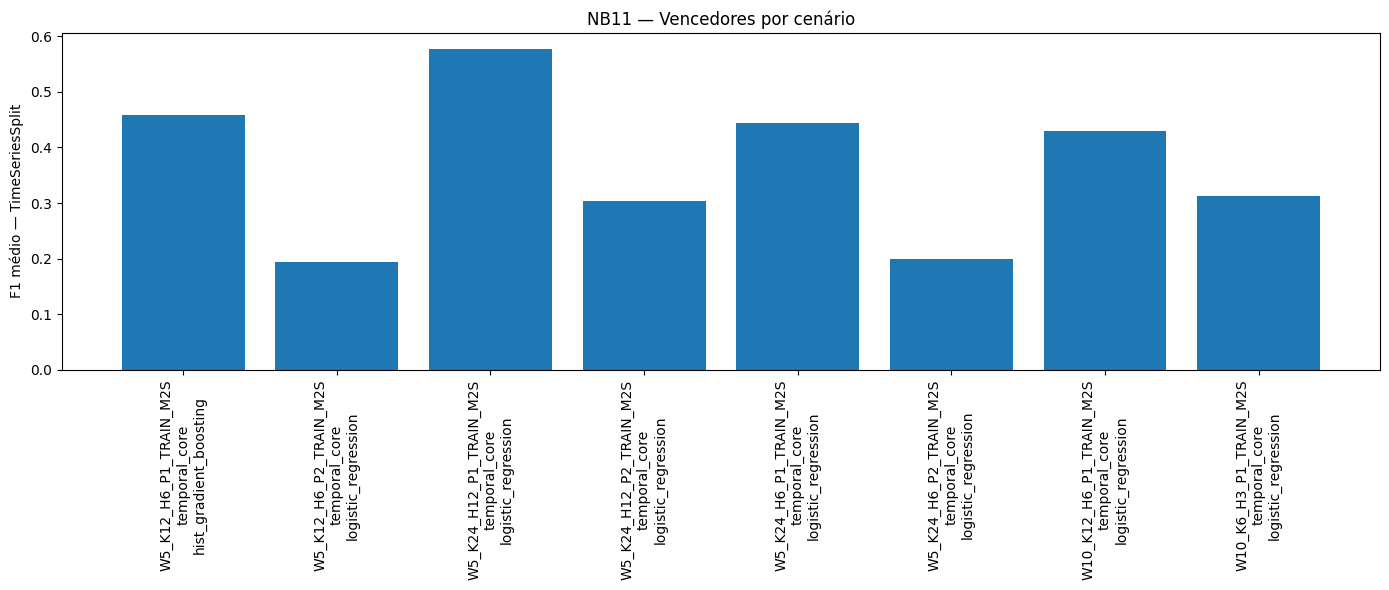

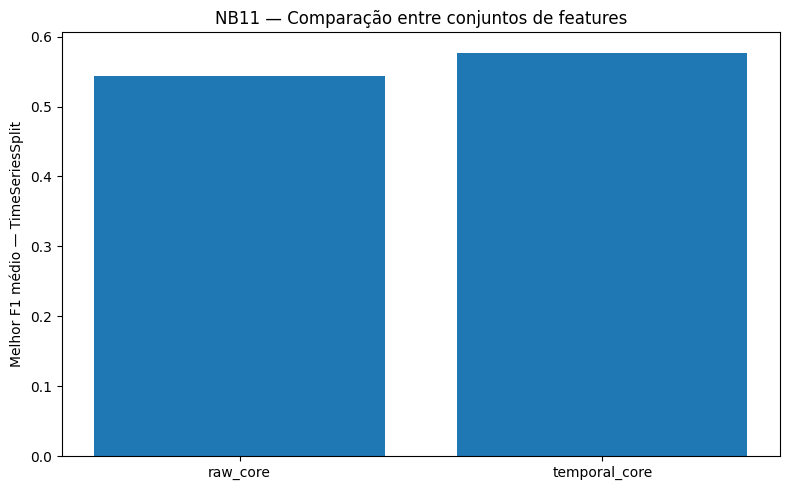

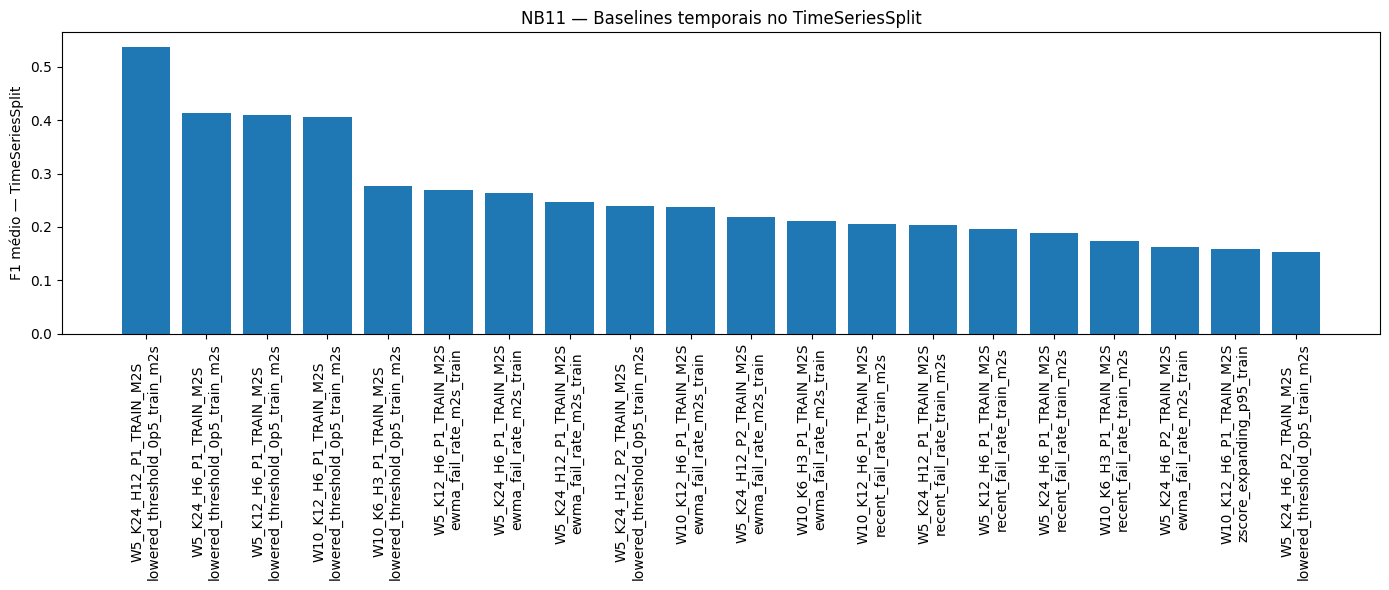

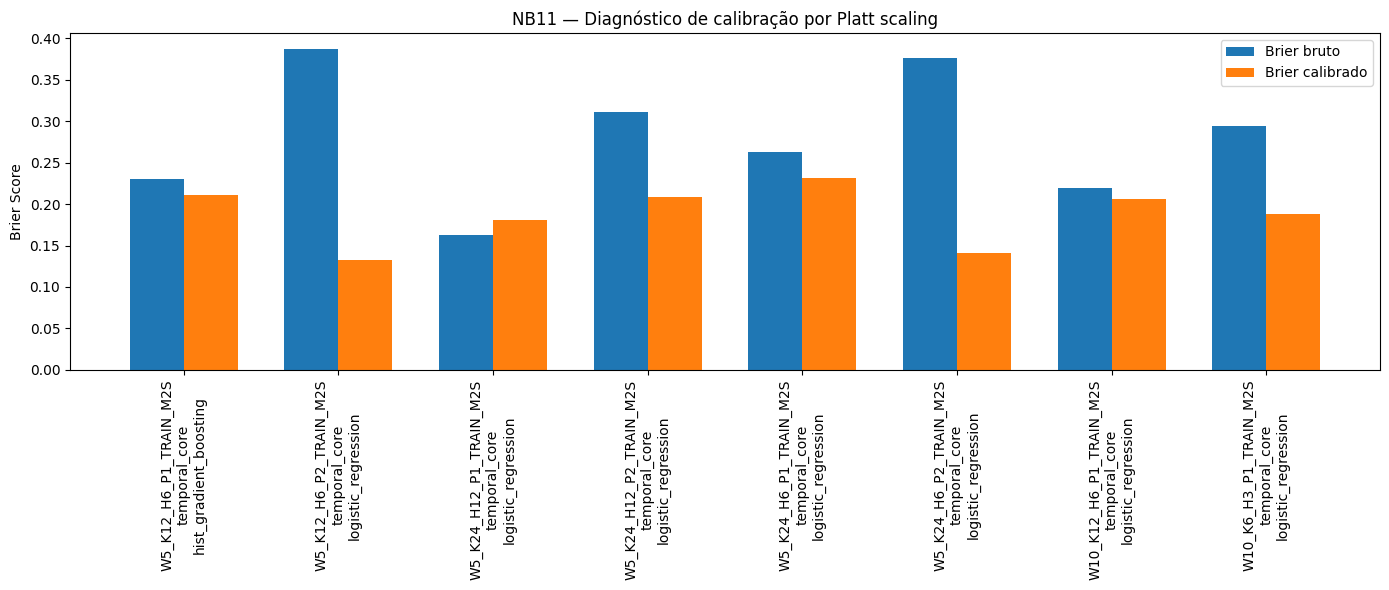

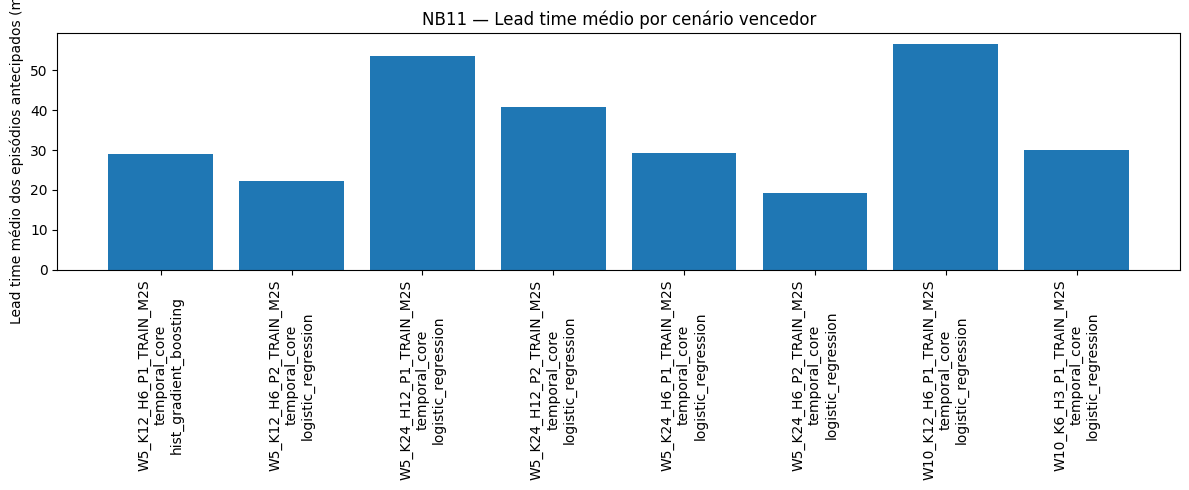


Resumo NB11:
{
  "notebook": "NB11",
  "title": "Baselines Temporais, Modelos Supervisionados e Lead Time Inicial",
  "executed_at": "2026-07-23 18:08:47",
  "n_scenarios_evaluated": 8,
  "validation_main": "TimeSeriesSplit",
  "validation_complementary": "fixed_80_20",
  "fixed_train_frac": 0.8,
  "n_splits_tscv": 5,
  "default_threshold": 0.5,
  "baseline_configuration": {
    "ewma_baseline_name": "ewma_fail_rate_m2s_train",
    "ewma_alpha": 0.3,
    "ewma_threshold_method": "m2s",
    "ewma_threshold_rule": "m2s: média_treino(EWMA) + 2*desvio_treino(EWMA); p95: percentil 95_treino(EWMA).",
    "ewma_causality_statement": "O EWMA em t usa fail_rate_t e o estado acumulado até t-1; o limiar é estimado exclusivamente no treino."
  },
  "winner": {
    "scenario_label": "W5_K24_H12_P1_TRAIN_M2S",
    "feature_set": "temporal_core",
    "model": "logistic_regression",
    "f1_tscv_mean": 0.5772970553519514,
    "f1_tscv_std": 0.24057162527769632,
    "recall_tscv_mean": 0.8335343612479

In [ ]:
# ============================================================
# NB11 — Baselines Temporais, Modelos Supervisionados e Lead Time
# Pipeline PPCOMP/DM — Dissertação de Mestrado
#
# Escopo do notebook:
#   1. Baselines causais no TimeSeriesSplit e no corte temporal fixo.
#   2. Comparação entre conjuntos normativos de atributos.
#   3. Atributos temporais causais reconstruídos quando ausentes.
#   4. Lead time calculado somente para episódios avaliáveis.
#   5. Governança do experimento complementar NB13/LSTM.
#   6. Baseline temporal EWMA causal sobre fail_rate.
#   7. Contrato de redundância e duplicidade do protocolo v1.2.
# ============================================================


# ============================================================
# 0. Imports e configuração geral
# ============================================================

import os
import json
import math
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    brier_score_loss,
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS_TSCV = 5
FIXED_TRAIN_FRAC = 0.80
DEFAULT_THRESHOLD = 0.50

# Baseline temporal trivial adicional: EWMA causal do fail_rate.
# A regra operacional usa apenas dados do treino para definir o limiar
# e mantém a recorrência do EWMA de forma causal ao entrar no teste.
# Métodos aceitos: "m2s" = média_treino + 2*desvio_treino; "p95" = percentil 95 do treino.
EWMA_ALPHA = 0.30
EWMA_THRESHOLD_METHOD = "m2s"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

print("NB11 iniciado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))


# ============================================================
# 1. Paths do projeto
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    BASE_DIR = Path("/content/drive/MyDrive/Mestrado")
else:
    BASE_DIR = Path.cwd()

DATA_DIR = BASE_DIR / "02-datasets"
FEATURES_DIR = DATA_DIR / "03-features"
MODELS_DIR = BASE_DIR / "03-models"
REPORTS_DIR = BASE_DIR / "04-reports"
NB11_DIR = REPORTS_DIR
NB11_LEGACY_DIR = REPORTS_DIR / "nb11"
FIGURES_DIR = REPORTS_DIR / "figures_nb11"

for p in [FEATURES_DIR, MODELS_DIR, REPORTS_DIR, NB11_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# Quarentena controlada da saída anterior do NB11.
# A área ativa é esvaziada antes da materialização da nova linhagem.
RUN_TIMESTAMP_FILE = datetime.now().strftime("%Y%m%d_%H%M%S")
BACKUP_DIR = REPORTS_DIR / "_backup_previous_artifacts" / RUN_TIMESTAMP_FILE / "nb11"
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

def quarantine_existing_nb11_artifacts():
    import shutil

    patterns = [
        "11_*.csv",
        "11_*.json",
        "11_*.parquet",
        "11_*.txt",
    ]

    moved = []

    for pattern in patterns:
        for path in REPORTS_DIR.glob(pattern):
            if path.is_file():
                target = BACKUP_DIR / path.name
                shutil.move(str(path), str(target))
                moved.append(str(path))

    if FIGURES_DIR.exists() and FIGURES_DIR.is_dir():
        target_dir = BACKUP_DIR / "figures_nb11"
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.move(str(FIGURES_DIR), str(target_dir))
        moved.append(str(FIGURES_DIR))

    if NB11_LEGACY_DIR.exists() and NB11_LEGACY_DIR.is_dir():
        target_dir = BACKUP_DIR / "legacy_nb11"
        if target_dir.exists():
            shutil.rmtree(target_dir)
        shutil.move(str(NB11_LEGACY_DIR), str(target_dir))
        moved.append(str(NB11_LEGACY_DIR))

    FIGURES_DIR.mkdir(parents=True, exist_ok=True)

    if moved:
        print(f"[QUARENTENA NB11] Saída anterior movida para: {BACKUP_DIR}")
    else:
        print("[QUARENTENA NB11] Nenhuma saída anterior localizada.")

quarantine_existing_nb11_artifacts()


print("BASE_DIR    :", BASE_DIR)
print("FEATURES_DIR:", FEATURES_DIR)
print("REPORTS_DIR :", REPORTS_DIR)
print("NB11_DIR    :", NB11_DIR)
print("FIGURES_DIR :", FIGURES_DIR)


# ============================================================
# 2. Arquivos de entrada do NB10
# ============================================================

ADVANCED_JSON = REPORTS_DIR / "10_scenario_advanced_to_nb11.json"
STATES_PARQUET = REPORTS_DIR / "10_scenario_series_states.parquet"
EPISODES_PARQUET = REPORTS_DIR / "10_scenario_episodes.parquet"
DECISIONS_CSV = REPORTS_DIR / "10_scenario_decisions.csv"

required_inputs = [
    ADVANCED_JSON,
    STATES_PARQUET,
    EPISODES_PARQUET,
    DECISIONS_CSV,
]

missing = [str(p) for p in required_inputs if not p.exists()]

if missing:
    raise FileNotFoundError(
        "Arquivos esperados do NB10 não encontrados:\n" + "\n".join(missing)
    )

print("Entradas do NB10 localizadas com sucesso.")


# ============================================================
# 3. Funções gerais
# ============================================================

def save_json(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


def read_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def safe_auc(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_ap(y_true, y_score):
    y_true = np.asarray(y_true)
    if len(y_true) == 0 or len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def safe_brier(y_true, y_score):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    if len(y_true) == 0:
        return np.nan
    return brier_score_loss(y_true, np.clip(y_score, 0, 1))


def compute_ece(y_true, y_score, n_bins=10):
    """
    Expected Calibration Error simples.
    Usado como diagnóstico da calibração.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if len(y_true) == 0:
        return np.nan

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left = bins[i]
        right = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_score >= left) & (y_score <= right)
        else:
            mask = (y_score >= left) & (y_score < right)

        if mask.sum() == 0:
            continue

        acc_bin = y_true[mask].mean()
        conf_bin = y_score[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc_bin - conf_bin)

    return float(ece)


def build_calibration_curve_df(
    y_true,
    score,
    stage,
    scenario_label,
    feature_set_name,
    model_name,
    n_bins=10,
):
    """
    Materializa a curva empírica de calibração ponto a ponto.

    Este artefato complementa 11_calibration_summary.csv: o resumo decide se a
    calibração melhorou Brier/ECE; a curva alimenta diretamente a Figura 7 do NB15.
    """
    y_true = np.asarray(y_true).astype(int)
    score = np.asarray(score).astype(float)

    mask = np.isfinite(score)
    y_true = y_true[mask]
    score = np.clip(score[mask], 0.0, 1.0)

    if len(y_true) == 0:
        return pd.DataFrame(columns=[
            "scenario_label",
            "feature_set",
            "model",
            "calibration_stage",
            "bin",
            "bin_left",
            "bin_right",
            "mean_pred",
            "frac_pos",
            "count",
        ])

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_id = np.digitize(score, bins, right=True)
    bin_id = np.clip(bin_id, 1, n_bins)

    rows = []
    for b in range(1, n_bins + 1):
        m = bin_id == b
        if m.sum() == 0:
            continue
        rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set_name,
            "model": model_name,
            "calibration_stage": stage,
            "bin": int(b),
            "bin_left": float(bins[b - 1]),
            "bin_right": float(bins[b]),
            "mean_pred": float(score[m].mean()),
            "frac_pos": float(y_true[m].mean()),
            "count": int(m.sum()),
        })

    return pd.DataFrame(rows)


def binary_metrics(y_true, y_score, threshold=0.5):
    """
    Métricas binárias padronizadas para modelos e baselines.
    y_score pode ser probabilidade, escore ou saída binária.
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    if len(y_true) == 0:
        return {
            "n": 0,
            "positive_rate": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "roc_auc": np.nan,
            "average_precision": np.nan,
            "brier": np.nan,
            "tn": 0,
            "fp": 0,
            "fn": 0,
            "tp": 0,
        }

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    return {
        "n": int(len(y_true)),
        "positive_rate": float(np.mean(y_true)),
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": float(safe_auc(y_true, y_score)) if not np.isnan(safe_auc(y_true, y_score)) else np.nan,
        "average_precision": float(safe_ap(y_true, y_score)) if not np.isnan(safe_ap(y_true, y_score)) else np.nan,
        "brier": float(safe_brier(y_true, y_score)) if not np.isnan(safe_brier(y_true, y_score)) else np.nan,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }


def false_alerts_per_day(y_true, y_score, window_minutes, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    false_alerts = int(((y_pred == 1) & (y_true == 0)).sum())
    total_days = (len(y_true) * window_minutes) / (60 * 24)

    return {
        "false_alerts": false_alerts,
        "false_alerts_per_day": float(false_alerts / total_days) if total_days > 0 else np.nan,
    }


def infer_scenario_column(df: pd.DataFrame):
    candidates = [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]

    for c in candidates:
        if c in df.columns:
            return c

    raise ValueError("Não foi possível identificar a coluna de cenário.")


def infer_episode_columns(df_episodes: pd.DataFrame):
    start_candidates = [
        "start_bucket_id",
        "episode_start_bucket_id",
        "start_bucket",
        "bucket_start",
        "start",
    ]

    end_candidates = [
        "end_bucket_id",
        "episode_end_bucket_id",
        "end_bucket",
        "bucket_end",
        "end",
    ]

    start_col = next((c for c in start_candidates if c in df_episodes.columns), None)
    end_col = next((c for c in end_candidates if c in df_episodes.columns), None)

    if start_col is None or end_col is None:
        raise ValueError(
            "Não foi possível identificar colunas de início/fim dos episódios."
        )

    return start_col, end_col


def scenario_to_dict_list(obj):
    """
    Normaliza o JSON do NB10 para lista de cenários.
    """
    if isinstance(obj, list):
        return obj

    if isinstance(obj, dict):
        for key in [
            "advanced_to_nb11",
            "scenarios",
            "advanced_scenarios",
            "items",
        ]:
            if key in obj and isinstance(obj[key], list):
                return obj[key]

        if all(isinstance(v, dict) for v in obj.values()):
            out = []
            for k, v in obj.items():
                vv = dict(v)
                vv.setdefault("scenario_label", k)
                out.append(vv)
            return out

    raise ValueError("Formato não reconhecido para 10_scenario_advanced_to_nb11.json")


def get_scenario_label(scen):
    for k in [
        "scenario_label",
        "scenario",
        "scenario_id",
        "config_label",
        "label",
    ]:
        if k in scen:
            return str(scen[k])

    raise ValueError(f"Cenário sem identificador reconhecido: {scen}")


def get_first_available(dct, keys, default=None):
    for k in keys:
        if k in dct and dct[k] is not None:
            return dct[k]
    return default


def parse_int_from_label(label, token, default=None):
    try:
        parts = str(label).split("_")
        for p in parts:
            if p.startswith(token):
                return int(p.replace(token, ""))
    except Exception:
        return default
    return default


# ============================================================
# 4. Carregamento dos artefatos do NB10
# ============================================================

advanced_raw = read_json(ADVANCED_JSON)
advanced_scenarios = scenario_to_dict_list(advanced_raw)

df_states_all = pd.read_parquet(STATES_PARQUET)
df_episodes_all = pd.read_parquet(EPISODES_PARQUET)
df_decisions = pd.read_csv(DECISIONS_CSV)

scenario_col_states = infer_scenario_column(df_states_all)
scenario_col_episodes = infer_scenario_column(df_episodes_all)

episode_start_col, episode_end_col = infer_episode_columns(df_episodes_all)

print("Cenários promovidos:", len(advanced_scenarios))
print("Coluna de cenário em states  :", scenario_col_states)
print("Coluna de cenário em episodes:", scenario_col_episodes)
print("Coluna início episódio        :", episode_start_col)
print("Coluna fim episódio           :", episode_end_col)
print("df_states_all:", df_states_all.shape)
print("df_episodes_all:", df_episodes_all.shape)


# ============================================================
# 5. Atributos temporais causais e contrato dos conjuntos
# ============================================================

RAW_CORE_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "event_LOST_count",
]

TEMPORAL_CORE_FEATURES = RAW_CORE_FEATURES + [
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

# Conjunto ampliado opcional. A coluna event_FAIL_count permanece no
# dataframe model-facing para proveniência, mas não integra preditores.
TEMPORAL_FULL_FEATURES = [
    "fail_rate",
    "n_events",
    "n_failed",
    "n_machines",
    "n_collections",
    "mean_priority",
    "mean_req_cpus",
    "mean_req_mem",
    "req_cpus_presence_rate",
    "req_mem_presence_rate",
    "event_SCHEDULE_count",
    "event_FINISH_count",
    "event_ENABLE_count",
    "event_LOST_count",
    "event_EVICT_count",
    "event_KILL_count",
    "lag_1",
    "lag_2",
    "lag_3",
    "rolling_mean_1h",
    "rolling_std_1h",
    "pct_change",
    "zscore_expanding",
]

FORBIDDEN_FEATURE_PATTERNS = [
    "target",
    "label",
    "state",
    "during",
    "before",
    "after",
    "critical",
    "episode",
    "future",
    "horizon",
    "bucket_start_us",
    "bucket_id",
    "time",
    "timestamp",
]

FORBIDDEN_PREDICTORS = {
    "event_FAIL_count",
    "y",
    "y_nb11",
    "target",
    "target_binary",
    "y_binary",
    "y_anticipation",
    "anticipation_target",
    "will_enter_during_h",
    "state",
    "is_critical",
    "episode_id",
    "eligible_supervised",
    "has_complete_horizon",
    "has_complete_horizon_nb11",
    "bucket_id",
    "bucket_start_us",
    "scenario_label",
}

EXPECTED_FEATURE_SET_CARDINALITY = {
    "raw_core": 6,
    "temporal_core": 13,
}

assert len(RAW_CORE_FEATURES) == 6
assert len(TEMPORAL_CORE_FEATURES) == 13
assert len(RAW_CORE_FEATURES) == len(set(RAW_CORE_FEATURES))
assert len(TEMPORAL_CORE_FEATURES) == len(set(TEMPORAL_CORE_FEATURES))
assert "event_FAIL_count" not in RAW_CORE_FEATURES
assert "event_FAIL_count" not in TEMPORAL_CORE_FEATURES
assert "event_FAIL_count" not in TEMPORAL_FULL_FEATURES


def add_causal_temporal_features(df: pd.DataFrame, window_minutes: int):
    """
    Reconstrói atributos temporais causais a partir de fail_rate.

    Todas as operações usam informação disponível até t ou anterior a t.
    """
    if "fail_rate" not in df.columns:
        raise ValueError("fail_rate é necessária para criar atributos temporais causais.")

    df = df.sort_values("bucket_id").copy()

    df["lag_1"] = df["fail_rate"].shift(1)
    df["lag_2"] = df["fail_rate"].shift(2)
    df["lag_3"] = df["fail_rate"].shift(3)

    rolling_window = max(int(round(60 / window_minutes)), 1)

    # Estatísticas históricas deslocadas para não usar o valor corrente.
    df["rolling_mean_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=1)
        .mean()
    )

    df["rolling_std_1h"] = (
        df["fail_rate"]
        .shift(1)
        .rolling(window=rolling_window, min_periods=2)
        .std(ddof=0)
    )

    previous = df["fail_rate"].shift(1)
    df["pct_change"] = (df["fail_rate"] - previous) / previous.replace(0, np.nan)

    expanding_mean = df["fail_rate"].shift(1).expanding(min_periods=2).mean()
    expanding_std = df["fail_rate"].shift(1).expanding(min_periods=2).std(ddof=0)

    df["zscore_expanding"] = (
        (df["fail_rate"] - expanding_mean) / expanding_std.replace(0, np.nan)
    )

    temporal_cols = [
        "lag_1",
        "lag_2",
        "lag_3",
        "rolling_mean_1h",
        "rolling_std_1h",
        "pct_change",
        "zscore_expanding",
    ]

    df[temporal_cols] = (
        df[temporal_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    return df


def _series_equal_na_safe(left: pd.Series, right: pd.Series) -> bool:
    """Compara valores posição a posição, tratando NaN simultâneo como igualdade."""
    if len(left) != len(right):
        return False
    equal = left.eq(right) | (left.isna() & right.isna())
    return bool(equal.all())


def assert_provenance_equality(df: pd.DataFrame, context: str):
    """
    Confirma a igualdade exata entre a coluna mantida e a coluna de proveniência.
    """
    required = {"n_failed", "event_FAIL_count"}
    missing = sorted(required - set(df.columns))
    if missing:
        raise ValueError(
            f"[{context}] Colunas obrigatórias para a auditoria de proveniência ausentes: {missing}"
        )

    if not _series_equal_na_safe(df["n_failed"], df["event_FAIL_count"]):
        mismatch = ~(
            df["n_failed"].eq(df["event_FAIL_count"])
            | (df["n_failed"].isna() & df["event_FAIL_count"].isna())
        )
        raise ValueError(
            f"[{context}] Divergência entre n_failed e event_FAIL_count "
            f"em {int(mismatch.sum())} linhas."
        )


def find_exact_duplicate_feature_pairs(df: pd.DataFrame, cols):
    """Localiza pares de preditores com valores exatamente iguais."""
    duplicates = []
    for i, left_name in enumerate(cols):
        for right_name in cols[i + 1:]:
            if _series_equal_na_safe(df[left_name], df[right_name]):
                duplicates.append((left_name, right_name))
    return duplicates


def validate_feature_list(cols, feature_set_name: str):
    """
    Aplica as proteções de vazamento e redundância ao vetor ativo.
    """
    if len(cols) != len(set(cols)):
        raise ValueError(
            f"[{feature_set_name}] Nomes repetidos no conjunto de preditores: {cols}"
        )

    forbidden_exact = sorted(set(cols) & FORBIDDEN_PREDICTORS)
    if forbidden_exact:
        raise ValueError(
            f"[{feature_set_name}] Preditores proibidos detectados: {forbidden_exact}"
        )

    bad_patterns = []
    for c in cols:
        lower = c.lower()
        if c == "fail_rate":
            continue
        if any(pattern in lower for pattern in FORBIDDEN_FEATURE_PATTERNS):
            bad_patterns.append(c)

    if bad_patterns:
        raise ValueError(
            f"[{feature_set_name}] Preditores com risco de vazamento: {bad_patterns}"
        )


def validate_feature_contract(
    df: pd.DataFrame,
    feature_sets: dict,
    scenario_label: str,
) -> pd.DataFrame:
    """
    Valida cardinalidade, proveniência, nomes e duplicidade por valores.
    A execução é interrompida antes do treinamento em qualquer não conformidade.
    """
    assert_provenance_equality(df, context=scenario_label)

    expected_lists = {
        "raw_core": RAW_CORE_FEATURES,
        "temporal_core": TEMPORAL_CORE_FEATURES,
    }

    audit_rows = []

    for feature_set_name, expected_cols in expected_lists.items():
        if feature_set_name not in feature_sets:
            raise ValueError(
                f"[{scenario_label}] Conjunto obrigatório ausente: {feature_set_name}"
            )

        active_cols = feature_sets[feature_set_name]
        expected_n = EXPECTED_FEATURE_SET_CARDINALITY[feature_set_name]

        if active_cols != expected_cols:
            raise ValueError(
                f"[{scenario_label}/{feature_set_name}] Composição diferente do contrato. "
                f"Esperado={expected_cols}; obtido={active_cols}"
            )

        if len(active_cols) != expected_n:
            raise ValueError(
                f"[{scenario_label}/{feature_set_name}] Cardinalidade {len(active_cols)}; "
                f"esperado {expected_n}."
            )

    for feature_set_name, active_cols in feature_sets.items():
        validate_feature_list(active_cols, feature_set_name)

        duplicate_pairs = find_exact_duplicate_feature_pairs(df, active_cols)
        if duplicate_pairs:
            raise ValueError(
                f"[{scenario_label}/{feature_set_name}] Duplicidade exata por valores "
                f"não justificada: {duplicate_pairs}"
            )

        audit_rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set_name,
            "n_features": int(len(active_cols)),
            "event_FAIL_count_in_predictors": bool("event_FAIL_count" in active_cols),
            "duplicate_pair_count": int(len(duplicate_pairs)),
            "duplicate_pairs": "",
            "provenance_columns_equal": True,
            "status": "PASS",
        })

    return pd.DataFrame(audit_rows)


def build_feature_sets(df: pd.DataFrame, scenario_label: str):
    """
    Constrói os conjuntos ativos e aplica o contrato normativo 6/13.
    """
    required_core = sorted(set(TEMPORAL_CORE_FEATURES) - set(df.columns))
    if required_core:
        raise ValueError(
            f"[{scenario_label}] Colunas obrigatórias ausentes para temporal_core: "
            f"{required_core}"
        )

    candidates = {
        "raw_core": list(RAW_CORE_FEATURES),
        "temporal_core": list(TEMPORAL_CORE_FEATURES),
        "temporal_full": [
            c for c in TEMPORAL_FULL_FEATURES
            if c in df.columns and pd.api.types.is_numeric_dtype(df[c])
        ],
    }

    feature_sets = {}
    seen = set()

    for name, cols in candidates.items():
        if not cols:
            continue

        validate_feature_list(cols, name)
        signature = tuple(cols)

        if signature in seen:
            continue

        seen.add(signature)
        feature_sets[name] = cols

    duplicate_audit = validate_feature_contract(
        df=df,
        feature_sets=feature_sets,
        scenario_label=scenario_label,
    )

    return feature_sets, duplicate_audit


# ============================================================
# 6. Construção/validação do alvo supervisionado
# ============================================================

def ensure_target_column(df: pd.DataFrame, scenario: dict):
    """
    Garante coluna y_nb11 para antecipação.

    Prioriza alvos já produzidos pelo NB10.
    Se não houver, reconstrói a partir do estado DURING e do horizonte H.
    """
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
    ]

    df = df.copy()

    for c in target_candidates:
        if c in df.columns:
            df["y_nb11"] = df[c].astype(int)

            if "state" in df.columns:
                df = df[df["state"].isin(["NORMAL", "BEFORE"])].copy()

            for hcol in ["has_complete_horizon", "complete_horizon"]:
                if hcol in df.columns:
                    df = df[df[hcol].astype(bool)].copy()

            return df

    if "state" not in df.columns:
        raise ValueError(
            "Nenhuma coluna alvo encontrada e coluna 'state' ausente para reconstrução."
        )

    label = get_scenario_label(scenario)

    h_windows = int(
        get_first_available(
            scenario,
            ["h_windows", "H", "h", "horizon_windows"],
            parse_int_from_label(label, "H", default=12),
        )
    )

    df = df.sort_values("bucket_id").reset_index(drop=True).copy()
    states = df["state"].astype(str).values
    during = (states == "DURING")

    y = np.zeros(len(df), dtype=int)

    for step in range(1, h_windows + 1):
        shifted = np.zeros(len(df), dtype=bool)
        shifted[:-step] = during[step:]
        y = np.logical_or(y, shifted)

    df["y_nb11"] = y.astype(int)

    # Remove janelas sem horizonte futuro completo.
    df["has_complete_horizon_nb11"] = False
    if len(df) > h_windows:
        df.loc[: len(df) - h_windows - 1, "has_complete_horizon_nb11"] = True

    df = df[
        df["state"].isin(["NORMAL", "BEFORE"])
        & df["has_complete_horizon_nb11"]
    ].copy()

    return df


# ============================================================
# 7. Baselines causais
# ============================================================

def get_train_m2s_threshold(scenario: dict, df_train: pd.DataFrame):
    """
    Recupera train_m2s do cenário.
    Se não existir no JSON, estima como média + 2 desvios no treino.
    """
    possible = [
        "train_m2s",
        "threshold_train_m2s",
        "limiar_train_m2s",
        "threshold",
        "critical_threshold",
    ]

    val = get_first_available(scenario, possible, None)

    if val is not None:
        try:
            return float(val)
        except Exception:
            pass

    if "fail_rate" not in df_train.columns:
        raise ValueError("fail_rate ausente para estimar train_m2s.")

    return float(df_train["fail_rate"].mean() + 2.0 * df_train["fail_rate"].std(ddof=0))


def baseline_majority_zero(df_train, df_eval, threshold_value=None):
    return np.zeros(len(df_eval), dtype=float), {}


def baseline_recent_fail_rate(df_train, df_eval, threshold_value):
    """
    Baseline temporal ingênuo causal:
    alerta se fail_rate da janela anterior ultrapassa train_m2s.

    Para a primeira janela de teste, usa a última janela do treino como passado.
    """
    if len(df_train) > 0:
        bridge = pd.concat([df_train.tail(1), df_eval], ignore_index=True)
        prev_fail_rate = bridge["fail_rate"].shift(1).iloc[1:].values
    else:
        prev_fail_rate = df_eval["fail_rate"].shift(1).fillna(0.0).values

    scores = (prev_fail_rate >= threshold_value).astype(float)

    return scores, {
        "baseline_threshold": float(threshold_value),
    }


def baseline_lowered_threshold(df_train, df_eval, threshold_value):
    """
    Baseline de limiar rebaixado:
    alerta se fail_rate_t >= 0,5 * train_m2s.
    """
    lowered = 0.5 * threshold_value
    scores = (df_eval["fail_rate"].values >= lowered).astype(float)

    return scores, {
        "baseline_threshold": float(lowered),
    }


def baseline_zscore_causal(df_train, df_eval, threshold_value=None):
    """
    Baseline z-score causal:
    limiar definido no treino como p95 do zscore_expanding.
    """
    if "zscore_expanding" not in df_train.columns or "zscore_expanding" not in df_eval.columns:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_expanding_unavailable",
        }

    z_train = (
        df_train["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(z_train) == 0:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "zscore_train_empty",
        }

    z_thr = float(np.nanpercentile(z_train.values, 95))

    scores = (
        df_eval["zscore_expanding"]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(-np.inf)
        .values >= z_thr
    ).astype(float)

    return scores, {
        "baseline_threshold": z_thr,
    }


def compute_ewma_fail_rate(values, alpha=EWMA_ALPHA):
    """
    Calcula EWMA causal sobre uma série de fail_rate.

    A atualização em t usa fail_rate_t e o estado acumulado até t-1:
        ewma_t = alpha * fail_rate_t + (1 - alpha) * ewma_{t-1}

    No contexto do NB11, isso é causal porque a previsão em t usa apenas
    informações observadas até a janela t.
    """
    values = (
        pd.Series(values, dtype="float64")
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    if len(values) == 0:
        return np.array([], dtype=float)

    return values.ewm(alpha=float(alpha), adjust=False).mean().values


def ewma_threshold_from_train(ewma_train, method=EWMA_THRESHOLD_METHOD):
    """
    Define o limiar do baseline EWMA usando exclusivamente o conjunto de treino.

    method="m2s": média_treino(EWMA) + 2 * desvio_treino(EWMA)
    method="p95": percentil 95_treino(EWMA)
    """
    ewma_train = np.asarray(ewma_train, dtype=float)
    ewma_train = ewma_train[np.isfinite(ewma_train)]

    if len(ewma_train) == 0:
        return np.nan, {
            "ewma_train_mean": np.nan,
            "ewma_train_std": np.nan,
            "ewma_train_p95": np.nan,
        }

    mean_train = float(np.mean(ewma_train))
    std_train = float(np.std(ewma_train, ddof=0))
    p95_train = float(np.nanpercentile(ewma_train, 95))

    method = str(method).lower().strip()

    if method == "p95":
        threshold = p95_train
    elif method == "m2s":
        threshold = mean_train + 2.0 * std_train
    else:
        raise ValueError(
            "EWMA_THRESHOLD_METHOD inválido. Use 'm2s' ou 'p95'."
        )

    return float(threshold), {
        "ewma_train_mean": mean_train,
        "ewma_train_std": std_train,
        "ewma_train_p95": p95_train,
    }


def baseline_ewma_fail_rate_causal(df_train, df_eval, threshold_value=None):
    """
    Baseline temporal EWMA causal sobre fail_rate.

    Objetivo metodológico:
    - ficar entre a regra instantânea de fail_rate e modelos temporais não triviais;
    - suavizar ruído de janelas isoladas;
    - testar se a persistência temporal simples já antecipa janelas de risco;
    - manter interpretação operacional simples e barata.

    Procedimento:
    1. Calcula EWMA no treino.
    2. Define o limiar apenas no treino.
    3. Continua o EWMA no teste a partir do estado acumulado no treino.
    4. Emite alarme binário quando EWMA_t >= limiar.
    """
    if "fail_rate" not in df_train.columns or "fail_rate" not in df_eval.columns:
        return np.zeros(len(df_eval), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "fail_rate_unavailable_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    train_fail = (
        df_train["fail_rate"]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .reset_index(drop=True)
    )

    eval_fail = (
        df_eval["fail_rate"]
        .astype(float)
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
        .reset_index(drop=True)
    )

    if len(eval_fail) == 0:
        return np.array([], dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "eval_empty_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    if len(train_fail) == 0:
        return np.zeros(len(eval_fail), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "train_empty_for_ewma",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        }

    ewma_train = compute_ewma_fail_rate(train_fail, alpha=EWMA_ALPHA)
    ewma_threshold, ewma_stats = ewma_threshold_from_train(
        ewma_train,
        method=EWMA_THRESHOLD_METHOD,
    )

    if not np.isfinite(ewma_threshold):
        return np.zeros(len(eval_fail), dtype=float), {
            "baseline_threshold": np.nan,
            "baseline_note": "ewma_threshold_not_finite",
            "ewma_alpha": float(EWMA_ALPHA),
            "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
            **ewma_stats,
        }

    # Mantém a memória temporal do EWMA ao passar do treino para o teste.
    combined_fail = pd.concat([train_fail, eval_fail], ignore_index=True)
    ewma_combined = compute_ewma_fail_rate(combined_fail, alpha=EWMA_ALPHA)
    ewma_eval = ewma_combined[len(train_fail):]

    scores = (ewma_eval >= ewma_threshold).astype(float)

    return scores, {
        "baseline_threshold": float(ewma_threshold),
        "baseline_score_type": "binary_alarm_from_causal_ewma_fail_rate",
        "ewma_alpha": float(EWMA_ALPHA),
        "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        **ewma_stats,
    }


BASELINES = {
    "majority_zero": baseline_majority_zero,
    "recent_fail_rate_train_m2s": baseline_recent_fail_rate,
    "lowered_threshold_0p5_train_m2s": baseline_lowered_threshold,
    "zscore_expanding_p95_train": baseline_zscore_causal,
    f"ewma_fail_rate_{EWMA_THRESHOLD_METHOD}_train": baseline_ewma_fail_rate_causal,
}


def evaluate_baselines_fixed(df, scenario, window_minutes):
    """
    Avalia baselines no corte fixo 80/20.
    """
    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    y_test = df_test["y_nb11"].astype(int).values

    train_m2s = get_train_m2s_threshold(scenario, df_train)

    records = []

    for baseline_name, baseline_func in BASELINES.items():
        scores, extra = baseline_func(df_train, df_test, train_m2s)

        metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            scores,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        records.append({
            "scenario_label": get_scenario_label(scenario),
            "baseline": baseline_name,
            "validation": "fixed_80_20",
            "fold": np.nan,
            "n_train": int(len(df_train)),
            "n_test": int(len(df_test)),
            "train_positive_rate": float(df_train["y_nb11"].mean()) if len(df_train) else np.nan,
            "test_positive_rate": float(df_test["y_nb11"].mean()) if len(df_test) else np.nan,
            "train_m2s": float(train_m2s),
            **extra,
            **metrics,
            **fa,
        })

    return pd.DataFrame(records)


def evaluate_baselines_tscv(df, scenario, window_minutes):
    """
    Avalia baselines no TimeSeriesSplit.
    """
    records = []

    y_all = df["y_nb11"].astype(int).values
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(df), start=1):
        df_train = df.iloc[tr_idx].copy()
        df_test = df.iloc[te_idx].copy()

        y_train = df_train["y_nb11"].astype(int).values
        y_test = df_test["y_nb11"].astype(int).values

        if len(np.unique(y_test)) < 2:
            continue

        train_m2s = get_train_m2s_threshold(scenario, df_train)

        for baseline_name, baseline_func in BASELINES.items():
            scores, extra = baseline_func(df_train, df_test, train_m2s)

            metrics = binary_metrics(y_test, scores, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(
                y_test,
                scores,
                window_minutes=window_minutes,
                threshold=DEFAULT_THRESHOLD,
            )

            records.append({
                "scenario_label": get_scenario_label(scenario),
                "baseline": baseline_name,
                "validation": "timeseries_split",
                "fold": int(fold_id),
                "n_train": int(len(df_train)),
                "n_test": int(len(df_test)),
                "train_positive_rate": float(np.mean(y_train)),
                "test_positive_rate": float(np.mean(y_test)),
                "train_m2s": float(train_m2s),
                **extra,
                **metrics,
                **fa,
            })

    return pd.DataFrame(records)


# ============================================================
# 8. Modelos supervisionados
# ============================================================

def make_models():
    return {
        "logistic_regression": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    solver="lbfgs",
                )),
            ]
        ),

        "random_forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=2,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced_subsample",
        ),

        "hist_gradient_boosting": HistGradientBoostingClassifier(
            max_iter=200,
            early_stopping=True,
            validation_fraction=0.1,
            random_state=RANDOM_STATE,
        ),
    }


def compute_sample_weight_balanced(y):
    y = np.asarray(y).astype(int)
    n = len(y)
    classes, counts = np.unique(y, return_counts=True)

    weights = np.ones(n, dtype=float)

    for cls, cnt in zip(classes, counts):
        weights[y == cls] = n / (len(classes) * cnt)

    return weights


def fit_model(model_name, estimator, X_train, y_train):
    est = clone(estimator)

    if model_name == "hist_gradient_boosting":
        sw = compute_sample_weight_balanced(y_train)
        est.fit(X_train, y_train, sample_weight=sw)
    else:
        est.fit(X_train, y_train)

    return est


def predict_score(estimator, X):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]

    if hasattr(estimator, "decision_function"):
        raw = estimator.decision_function(X)
        return 1.0 / (1.0 + np.exp(-raw))

    return estimator.predict(X).astype(float)


def evaluate_models_for_feature_set(df, scenario, feature_set_name, feature_cols, window_minutes, h_windows):
    """
    Avalia modelos para um cenário e um conjunto de features.
    """
    df = df.copy()

    df[feature_cols] = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    X = df[feature_cols].values
    y = df["y_nb11"].astype(int).values

    models = make_models()
    tscv = TimeSeriesSplit(n_splits=N_SPLITS_TSCV)

    tscv_records = []
    fixed_records = []
    raw_score_records = []

    # ------------------------------------------------------------
    # TimeSeriesSplit
    # ------------------------------------------------------------

    for model_name, estimator in models.items():
        for fold_id, (tr_idx, te_idx) in enumerate(tscv.split(X), start=1):
            X_train, X_test = X[tr_idx], X[te_idx]
            y_train, y_test = y[tr_idx], y[te_idx]

            if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
                continue

            est = fit_model(model_name, estimator, X_train, y_train)
            score_test = predict_score(est, X_test)

            metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
            fa = false_alerts_per_day(
                y_test,
                score_test,
                window_minutes=window_minutes,
                threshold=DEFAULT_THRESHOLD,
            )

            tscv_records.append({
                "scenario_label": get_scenario_label(scenario),
                "feature_set": feature_set_name,
                "model": model_name,
                "validation": "timeseries_split",
                "fold": int(fold_id),
                "n_train": int(len(y_train)),
                "n_test": int(len(y_test)),
                "train_positive_rate": float(y_train.mean()),
                "test_positive_rate": float(y_test.mean()),
                "n_features": int(len(feature_cols)),
                "features": "|".join(feature_cols),
                **metrics,
                **fa,
            })

    # ------------------------------------------------------------
    # Corte fixo 80/20
    # ------------------------------------------------------------

    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values

    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    for model_name, estimator in models.items():
        if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
            continue

        est = fit_model(model_name, estimator, X_train, y_train)
        score_test = predict_score(est, X_test)

        metrics = binary_metrics(y_test, score_test, DEFAULT_THRESHOLD)
        fa = false_alerts_per_day(
            y_test,
            score_test,
            window_minutes=window_minutes,
            threshold=DEFAULT_THRESHOLD,
        )

        fixed_records.append({
            "scenario_label": get_scenario_label(scenario),
            "feature_set": feature_set_name,
            "model": model_name,
            "validation": "fixed_80_20",
            "n_train": int(len(y_train)),
            "n_test": int(len(y_test)),
            "train_positive_rate": float(y_train.mean()),
            "test_positive_rate": float(y_test.mean()),
            "n_features": int(len(feature_cols)),
            "features": "|".join(feature_cols),
            **metrics,
            **fa,
        })

        tmp = df_test[["bucket_id"]].copy()
        tmp["scenario_label"] = get_scenario_label(scenario)
        tmp["feature_set"] = feature_set_name
        tmp["model"] = model_name
        tmp["validation"] = "fixed_80_20"
        tmp["y_true"] = y_test
        tmp["score_raw"] = score_test
        tmp["window_minutes"] = int(window_minutes)
        tmp["h_windows"] = int(h_windows)
        tmp["n_features"] = int(len(feature_cols))
        tmp["features"] = "|".join(feature_cols)

        raw_score_records.append(tmp)

    df_tscv = pd.DataFrame(tscv_records)
    df_fixed = pd.DataFrame(fixed_records)
    df_raw_scores = pd.concat(raw_score_records, ignore_index=True) if raw_score_records else pd.DataFrame()

    return df_tscv, df_fixed, df_raw_scores


# ============================================================
# 9. Resumos
# ============================================================

def summarize_model_metrics(df_tscv):
    if df_tscv.empty:
        return pd.DataFrame()

    rows = []

    group_cols = [
        "scenario_label",
        "feature_set",
        "model",
    ]

    for keys, g in df_tscv.groupby(group_cols):
        scenario_label, feature_set, model = keys

        rows.append({
            "scenario_label": scenario_label,
            "feature_set": feature_set,
            "model": model,
            "n_folds_valid": int(g["fold"].nunique()),
            "n_features": int(g["n_features"].iloc[0]),
            "features": str(g["features"].iloc[0]),

            "accuracy_tscv_mean": float(g["accuracy"].mean()),
            "accuracy_tscv_std": float(g["accuracy"].std(ddof=0)),

            "precision_tscv_mean": float(g["precision"].mean()),
            "precision_tscv_std": float(g["precision"].std(ddof=0)),

            "recall_tscv_mean": float(g["recall"].mean()),
            "recall_tscv_std": float(g["recall"].std(ddof=0)),

            "f1_tscv_mean": float(g["f1"].mean()),
            "f1_tscv_std": float(g["f1"].std(ddof=0)),

            "roc_auc_tscv_mean": float(g["roc_auc"].mean()),
            "roc_auc_tscv_std": float(g["roc_auc"].std(ddof=0)),

            "average_precision_tscv_mean": float(g["average_precision"].mean()),
            "average_precision_tscv_std": float(g["average_precision"].std(ddof=0)),

            "brier_tscv_mean": float(g["brier"].mean()),
            "brier_tscv_std": float(g["brier"].std(ddof=0)),

            "false_alerts_per_day_tscv_mean": float(g["false_alerts_per_day"].mean()),
            "false_alerts_per_day_tscv_std": float(g["false_alerts_per_day"].std(ddof=0)),
        })

    return pd.DataFrame(rows)


def summarize_baselines(df_baselines):
    if df_baselines.empty:
        return pd.DataFrame()

    rows = []

    group_cols = [
        "scenario_label",
        "baseline",
        "validation",
    ]

    for keys, g in df_baselines.groupby(group_cols):
        scenario_label, baseline, validation = keys

        rows.append({
            "scenario_label": scenario_label,
            "baseline": baseline,
            "validation": validation,
            "n_folds_valid": int(g["fold"].dropna().nunique()) if validation == "timeseries_split" else np.nan,

            "accuracy_mean": float(g["accuracy"].mean()),
            "precision_mean": float(g["precision"].mean()),
            "recall_mean": float(g["recall"].mean()),
            "f1_mean": float(g["f1"].mean()),
            "roc_auc_mean": float(g["roc_auc"].mean()),
            "average_precision_mean": float(g["average_precision"].mean()),
            "brier_mean": float(g["brier"].mean()),
            "false_alerts_per_day_mean": float(g["false_alerts_per_day"].mean()),
        })

    return pd.DataFrame(rows)


def summarize_feature_sets(df_summary):
    if df_summary.empty:
        return pd.DataFrame()

    rows = []

    for feature_set, g in df_summary.groupby("feature_set"):
        best = g.sort_values(
            ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
            ascending=[False, False, False],
        ).iloc[0]

        rows.append({
            "feature_set": feature_set,
            "best_scenario_label": best["scenario_label"],
            "best_model": best["model"],
            "best_f1_tscv_mean": float(best["f1_tscv_mean"]),
            "best_f1_tscv_std": float(best["f1_tscv_std"]),
            "best_recall_tscv_mean": float(best["recall_tscv_mean"]),
            "best_precision_tscv_mean": float(best["precision_tscv_mean"]),
            "best_average_precision_tscv_mean": float(best["average_precision_tscv_mean"]),
            "best_n_features": int(best["n_features"]),
            "features": best["features"],
        })

    return pd.DataFrame(rows)


# ============================================================
# 10. Calibração
# ============================================================

def calibrate_winner_fixed_split(df, scenario, feature_set_name, feature_cols, model_name, window_minutes, h_windows):
    """
    Calibração diagnóstica por Platt scaling no vencedor do cenário.
    Usa apenas o trecho de treino para ajustar modelo e calibrador.
    Aplica no teste fixo.
    """
    df = df.copy()

    df[feature_cols] = (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0.0)
    )

    n = len(df)
    split_idx = int(np.floor(n * FIXED_TRAIN_FRAC))

    df_train = df.iloc[:split_idx].copy()
    df_test = df.iloc[split_idx:].copy()

    X_train = df_train[feature_cols].values
    y_train = df_train["y_nb11"].astype(int).values

    X_test = df_test[feature_cols].values
    y_test = df_test["y_nb11"].astype(int).values

    if len(np.unique(y_train)) < 2 or len(np.unique(y_test)) < 2:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    estimator = make_models()[model_name]
    base_est = fit_model(model_name, estimator, X_train, y_train)

    score_raw = predict_score(base_est, X_test)

    try:
        calibrator = CalibratedClassifierCV(
            estimator=base_est,
            method="sigmoid",
            cv="prefit",
        )
    except TypeError:
        calibrator = CalibratedClassifierCV(
            base_estimator=base_est,
            method="sigmoid",
            cv="prefit",
        )

    calibrator.fit(X_train, y_train)
    score_calibrated = calibrator.predict_proba(X_test)[:, 1]

    raw_brier = safe_brier(y_test, score_raw)
    cal_brier = safe_brier(y_test, score_calibrated)

    raw_ece = compute_ece(y_test, score_raw)
    cal_ece = compute_ece(y_test, score_calibrated)

    joint_improvement = bool(cal_brier < raw_brier and cal_ece < raw_ece)
    calibration_statement = "relative_risk_score_preferred"

    df_calibration = pd.DataFrame([{
        "scenario_label": get_scenario_label(scenario),
        "feature_set": feature_set_name,
        "model": model_name,
        "calibration_method": "platt_sigmoid_prefit_train_only",
        "brier_raw": float(raw_brier),
        "brier_calibrated": float(cal_brier),
        "ece_raw": float(raw_ece),
        "ece_calibrated": float(cal_ece),
        "roc_auc_raw": float(safe_auc(y_test, score_raw)) if not np.isnan(safe_auc(y_test, score_raw)) else np.nan,
        "roc_auc_calibrated": float(safe_auc(y_test, score_calibrated)) if not np.isnan(safe_auc(y_test, score_calibrated)) else np.nan,
        "average_precision_raw": float(safe_ap(y_test, score_raw)) if not np.isnan(safe_ap(y_test, score_raw)) else np.nan,
        "average_precision_calibrated": float(safe_ap(y_test, score_calibrated)) if not np.isnan(safe_ap(y_test, score_calibrated)) else np.nan,
        "brier_improved": bool(cal_brier < raw_brier),
        "ece_improved": bool(cal_ece < raw_ece),
        "diagnostic_joint_improvement": joint_improvement,
        "operational_calibration_adopted": False,
        "calibration_statement": calibration_statement,
    }])

    df_scores = df_test[["bucket_id"]].copy()
    df_scores["scenario_label"] = get_scenario_label(scenario)
    df_scores["feature_set"] = feature_set_name
    df_scores["model"] = model_name
    df_scores["validation"] = "fixed_80_20"
    df_scores["y_true"] = y_test
    df_scores["score_raw"] = score_raw
    df_scores["score_calibrated"] = score_calibrated
    df_scores["window_minutes"] = int(window_minutes)
    df_scores["h_windows"] = int(h_windows)
    df_scores["n_features"] = int(len(feature_cols))
    df_scores["features"] = "|".join(feature_cols)

    df_calibration_curve = pd.concat(
        [
            build_calibration_curve_df(
                y_true=y_test,
                score=score_raw,
                stage="before",
                scenario_label=get_scenario_label(scenario),
                feature_set_name=feature_set_name,
                model_name=model_name,
                n_bins=10,
            ),
            build_calibration_curve_df(
                y_true=y_test,
                score=score_calibrated,
                stage="after",
                scenario_label=get_scenario_label(scenario),
                feature_set_name=feature_set_name,
                model_name=model_name,
                n_bins=10,
            ),
        ],
        ignore_index=True,
    )

    return df_calibration, df_scores, df_calibration_curve


# ============================================================
# 11. Lead time e antecipação por episódio
# ============================================================

def compute_episode_anticipation(
    df_scores: pd.DataFrame,
    df_episodes: pd.DataFrame,
    scenario_label: str,
    h_windows: int,
    window_minutes: int,
    score_col: str = "score_calibrated",
    threshold: float = 0.5,
):
    """
    Calcula lead time por episódio.

    Um episódio entra no denominador somente quando o intervalo
    [episode_start - H, episode_start - 1] possuir escores disponíveis.
    Isso evita misturar episódios fora do trecho efetivamente pontuado.
    """
    eps = df_episodes[
        df_episodes[scenario_col_episodes].astype(str) == str(scenario_label)
    ].copy()

    if eps.empty or df_scores.empty:
        return pd.DataFrame(), {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

    score_buckets = set(df_scores["bucket_id"].astype(int).tolist())
    score_lookup = df_scores.set_index("bucket_id")[score_col].to_dict()

    rows = []

    for _, ep in eps.iterrows():
        ep_start = int(ep[episode_start_col])
        ep_end = int(ep[episode_end_col])

        previous_window = list(range(ep_start - h_windows, ep_start))

        # Episódio avaliável apenas se todas as H janelas anteriores têm score.
        is_evaluable = all(b in score_buckets for b in previous_window)

        if not is_evaluable:
            continue

        alert_buckets = [
            b for b in previous_window
            if score_lookup.get(b, -np.inf) >= threshold
        ]

        if len(alert_buckets) > 0:
            first_alert_bucket = int(min(alert_buckets))
            lead_windows = int(ep_start - first_alert_bucket)
            anticipated = 1
        else:
            first_alert_bucket = np.nan
            lead_windows = np.nan
            anticipated = 0

        rows.append({
            "scenario_label": scenario_label,
            "episode_start_bucket_id": ep_start,
            "episode_end_bucket_id": ep_end,
            "h_windows": int(h_windows),
            "window_minutes": int(window_minutes),
            "score_col": score_col,
            "threshold": float(threshold),
            "anticipated": int(anticipated),
            "first_alert_bucket_id": first_alert_bucket,
            "lead_time_windows": lead_windows,
            "lead_time_minutes": lead_windows * window_minutes if not pd.isna(lead_windows) else np.nan,
        })

    df_detail = pd.DataFrame(rows)

    if df_detail.empty:
        summary = {
            "scenario_label": scenario_label,
            "n_total_episodes_in_scenario": int(len(eps)),
            "n_evaluable_episodes": 0,
            "n_anticipated": 0,
            "episode_anticipation_rate": np.nan,
            "lead_time_windows_mean": np.nan,
            "lead_time_minutes_mean": np.nan,
            "lead_time_windows_median": np.nan,
            "lead_time_minutes_median": np.nan,
        }

        return df_detail, summary

    anticipated_df = df_detail[df_detail["anticipated"] == 1]

    summary = {
        "scenario_label": scenario_label,
        "n_total_episodes_in_scenario": int(len(eps)),
        "n_evaluable_episodes": int(len(df_detail)),
        "n_anticipated": int(df_detail["anticipated"].sum()),
        "episode_anticipation_rate": float(df_detail["anticipated"].mean()),
        "lead_time_windows_mean": float(anticipated_df["lead_time_windows"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_mean": float(anticipated_df["lead_time_minutes"].mean()) if len(anticipated_df) else np.nan,
        "lead_time_windows_median": float(anticipated_df["lead_time_windows"].median()) if len(anticipated_df) else np.nan,
        "lead_time_minutes_median": float(anticipated_df["lead_time_minutes"].median()) if len(anticipated_df) else np.nan,
    }

    return df_detail, summary


# ============================================================
# 12. Avaliação completa de um cenário
# ============================================================


def prepare_scenario_full_feature_frame(scenario):
    """
    Constrói a série completa do cenário com features temporais causais.

    Este artefato é importante para notebooks posteriores, especialmente o NB13,
    porque preserva a continuidade temporal e materializa as mesmas features
    causais reconstruídas pelo NB11.
    """
    scenario_label = get_scenario_label(scenario)

    window_minutes = int(
        get_first_available(
            scenario,
            ["window_minutes", "w_minutes", "W", "granularity_minutes"],
            parse_int_from_label(scenario_label, "W", default=5),
        )
    )

    h_windows = int(
        get_first_available(
            scenario,
            ["h_windows", "H", "h", "horizon_windows"],
            parse_int_from_label(scenario_label, "H", default=12),
        )
    )

    df = df_states_all[
        df_states_all[scenario_col_states].astype(str) == str(scenario_label)
    ].copy()

    if df.empty:
        raise ValueError(f"Nenhuma linha encontrada em states para {scenario_label}.")

    if "bucket_id" not in df.columns:
        raise ValueError("Coluna bucket_id é obrigatória.")

    df = df.sort_values("bucket_id").reset_index(drop=True)

    # Materializa no dataframe completo as features temporais causais do NB11.
    df = add_causal_temporal_features(df, window_minutes)

    # Mantém o alvo original do NB10, quando disponível, sem usar como feature.
    target_candidates = [
        "y",
        "target",
        "target_binary",
        "y_binary",
        "y_anticipation",
        "anticipation_target",
        "will_enter_during_h",
    ]

    if "y_nb11" in df.columns:
        df = df.drop(columns=["y_nb11"])

    target_col = None
    for c in target_candidates:
        if c in df.columns:
            target_col = c
            df["y_nb11"] = df[c].astype(int)
            break

    if target_col is None and "state" in df.columns:
        states = df["state"].astype(str).values
        during = (states == "DURING")
        y = np.zeros(len(df), dtype=int)

        for step in range(1, h_windows + 1):
            shifted = np.zeros(len(df), dtype=bool)
            shifted[:-step] = during[step:]
            y = np.logical_or(y, shifted)

        df["y_nb11"] = y.astype(int)
        target_col = "reconstructed_from_state"

    if "eligible_supervised" not in df.columns:
        df["eligible_supervised"] = False

        if "state" in df.columns:
            valid_state = df["state"].isin(["NORMAL", "BEFORE"])
        else:
            valid_state = pd.Series(True, index=df.index)

        has_horizon = pd.Series(False, index=df.index)
        if len(df) > h_windows:
            has_horizon.iloc[: len(df) - h_windows] = True

        df.loc[valid_state & has_horizon, "eligible_supervised"] = True

    df["scenario_label"] = scenario_label
    df["window_minutes_nb11"] = int(window_minutes)
    df["h_windows_nb11"] = int(h_windows)
    df["target_source_nb11"] = str(target_col)

    return df, window_minutes, h_windows


def prepare_scenario_dataframe(scenario):
    scenario_label = get_scenario_label(scenario)

    df_full, window_minutes, h_windows = prepare_scenario_full_feature_frame(scenario)

    # Garante alvo e restringe à tarefa supervisionada efetivamente usada no NB11.
    df = ensure_target_column(df_full, scenario)

    df = df.sort_values("bucket_id").reset_index(drop=True)

    feature_sets, duplicate_audit = build_feature_sets(
        df=df,
        scenario_label=scenario_label,
    )

    return (
        df,
        feature_sets,
        duplicate_audit,
        window_minutes,
        h_windows,
        df_full,
    )


def evaluate_scenario(scenario):
    scenario_label = get_scenario_label(scenario)

    print("\n" + "=" * 90)
    print("Cenário:", scenario_label)
    print("=" * 90)

    (
        df,
        feature_sets,
        duplicate_audit,
        window_minutes,
        h_windows,
        df_full,
    ) = prepare_scenario_dataframe(scenario)

    y = df["y_nb11"].astype(int).values

    print("Linhas supervisionadas:", len(df))
    print("Taxa positiva:", round(float(y.mean()), 4))
    print("window_minutes:", window_minutes)
    print("h_windows:", h_windows)
    print("Feature sets disponíveis:")
    for name, cols in feature_sets.items():
        print("  -", name, len(cols), "features")

    # Baselines.
    df_baselines_fixed = evaluate_baselines_fixed(df, scenario, window_minutes)
    df_baselines_tscv = evaluate_baselines_tscv(df, scenario, window_minutes)
    df_baselines = pd.concat([df_baselines_fixed, df_baselines_tscv], ignore_index=True)

    # Modelos por conjunto de features.
    tscv_parts = []
    fixed_parts = []
    raw_score_parts = []

    for feature_set_name, feature_cols in feature_sets.items():
        print("Avaliando feature_set:", feature_set_name)

        df_tscv, df_fixed, df_raw_scores = evaluate_models_for_feature_set(
            df=df,
            scenario=scenario,
            feature_set_name=feature_set_name,
            feature_cols=feature_cols,
            window_minutes=window_minutes,
            h_windows=h_windows,
        )

        tscv_parts.append(df_tscv)
        fixed_parts.append(df_fixed)
        raw_score_parts.append(df_raw_scores)

    df_tscv = pd.concat(tscv_parts, ignore_index=True) if tscv_parts else pd.DataFrame()
    df_fixed = pd.concat(fixed_parts, ignore_index=True) if fixed_parts else pd.DataFrame()
    df_raw_scores = pd.concat(raw_score_parts, ignore_index=True) if raw_score_parts else pd.DataFrame()

    df_summary = summarize_model_metrics(df_tscv)

    if df_summary.empty:
        raise ValueError(f"Resumo vazio para {scenario_label}.")

    df_summary = df_summary.sort_values(
        ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
        ascending=[False, False, False],
    ).reset_index(drop=True)

    df_summary["is_winner_tscv"] = False
    df_summary.loc[0, "is_winner_tscv"] = True

    winner = df_summary.iloc[0].to_dict()

    print("Vencedor do cenário:")
    print("  feature_set:", winner["feature_set"])
    print("  model      :", winner["model"])
    print("  F1 TSCV    :", round(float(winner["f1_tscv_mean"]), 4))

    # Calibração do vencedor do cenário.
    winner_feature_set = winner["feature_set"]
    winner_model = winner["model"]
    winner_features = feature_sets[winner_feature_set]

    df_calibration, df_scores_calibrated, df_calibration_curve = calibrate_winner_fixed_split(
        df=df,
        scenario=scenario,
        feature_set_name=winner_feature_set,
        feature_cols=winner_features,
        model_name=winner_model,
        window_minutes=window_minutes,
        h_windows=h_windows,
    )

    # Lead time do vencedor do cenário.
    df_lead_detail = pd.DataFrame()
    df_lead_summary = pd.DataFrame()

    if not df_scores_calibrated.empty:
        df_lead_detail, lead_summary = compute_episode_anticipation(
            df_scores=df_scores_calibrated,
            df_episodes=df_episodes_all,
            scenario_label=scenario_label,
            h_windows=h_windows,
            window_minutes=window_minutes,
            score_col="score_calibrated",
            threshold=DEFAULT_THRESHOLD,
        )

        lead_summary["feature_set"] = winner_feature_set
        lead_summary["model"] = winner_model
        lead_summary["validation"] = "fixed_80_20"
        lead_summary["score_col"] = "score_calibrated"
        lead_summary["threshold"] = DEFAULT_THRESHOLD

        df_lead_summary = pd.DataFrame([lead_summary])

    return {
        "scenario_label": scenario_label,
        "df_prepared": df,
        "df_sequence_input": df_full,
        "feature_sets": feature_sets,
        "df_duplicate_audit": duplicate_audit,
        "df_baselines": df_baselines,
        "df_tscv": df_tscv,
        "df_fixed": df_fixed,
        "df_raw_scores": df_raw_scores,
        "df_summary": df_summary,
        "df_calibration": df_calibration,
        "df_calibration_curve": df_calibration_curve,
        "df_scores_calibrated": df_scores_calibrated,
        "df_lead_detail": df_lead_detail,
        "df_lead_summary": df_lead_summary,
    }


# ============================================================
# 13. Execução dos 8 cenários promovidos
# ============================================================

all_baselines = []
all_tscv = []
all_fixed = []
all_raw_scores = []
all_summary = []
all_calibration = []
all_calibration_curve = []
all_scores_calibrated = []
all_lead_detail = []
all_lead_summary = []
all_model_input = []
all_sequence_input = []
all_duplicate_audit = []

scenario_prepared_info = []

for scen in advanced_scenarios:
    result = evaluate_scenario(scen)

    all_baselines.append(result["df_baselines"])
    all_tscv.append(result["df_tscv"])
    all_fixed.append(result["df_fixed"])
    all_raw_scores.append(result["df_raw_scores"])
    all_summary.append(result["df_summary"])
    all_calibration.append(result["df_calibration"])
    all_calibration_curve.append(result["df_calibration_curve"])
    all_scores_calibrated.append(result["df_scores_calibrated"])
    all_lead_detail.append(result["df_lead_detail"])
    all_lead_summary.append(result["df_lead_summary"])

    model_input_df = result["df_prepared"].copy()
    model_input_df["scenario_label"] = result["scenario_label"]
    all_model_input.append(model_input_df)

    sequence_input_df = result["df_sequence_input"].copy()
    sequence_input_df["scenario_label"] = result["scenario_label"]
    all_sequence_input.append(sequence_input_df)
    all_duplicate_audit.append(result["df_duplicate_audit"])

    scenario_prepared_info.append({
        "scenario_label": result["scenario_label"],
        "n_rows_supervised": int(len(result["df_prepared"])),
        "positive_rate": float(result["df_prepared"]["y_nb11"].mean()),
        "feature_contract_status": "PASS",
        "provenance_columns_equal": True,
        "feature_sets": {
            name: {
                "n_features": len(cols),
                "features": cols,
            }
            for name, cols in result["feature_sets"].items()
        },
    })

df_baselines_all = pd.concat(all_baselines, ignore_index=True) if all_baselines else pd.DataFrame()
df_tscv_all = pd.concat(all_tscv, ignore_index=True) if all_tscv else pd.DataFrame()
df_fixed_all = pd.concat(all_fixed, ignore_index=True) if all_fixed else pd.DataFrame()
df_raw_scores_all = pd.concat(all_raw_scores, ignore_index=True) if all_raw_scores else pd.DataFrame()
df_summary_all = pd.concat(all_summary, ignore_index=True) if all_summary else pd.DataFrame()
df_calibration_all = pd.concat(all_calibration, ignore_index=True) if all_calibration else pd.DataFrame()
df_calibration_curve_all = pd.concat(all_calibration_curve, ignore_index=True) if all_calibration_curve else pd.DataFrame()
df_scores_calibrated_all = pd.concat(all_scores_calibrated, ignore_index=True) if all_scores_calibrated else pd.DataFrame()
df_lead_detail_all = pd.concat(all_lead_detail, ignore_index=True) if all_lead_detail else pd.DataFrame()
df_lead_summary_all = pd.concat(all_lead_summary, ignore_index=True) if all_lead_summary else pd.DataFrame()
df_model_input_all = pd.concat(all_model_input, ignore_index=True) if all_model_input else pd.DataFrame()
df_sequence_input_all = pd.concat(all_sequence_input, ignore_index=True) if all_sequence_input else pd.DataFrame()
df_duplicate_audit_all = pd.concat(all_duplicate_audit, ignore_index=True) if all_duplicate_audit else pd.DataFrame()

df_baselines_summary = summarize_baselines(df_baselines_all)
df_feature_set_summary = summarize_feature_sets(df_summary_all)

print("\nExecução completa concluída.")
print("df_baselines_all       :", df_baselines_all.shape)
print("df_tscv_all            :", df_tscv_all.shape)
print("df_fixed_all           :", df_fixed_all.shape)
print("df_summary_all         :", df_summary_all.shape)
print("df_calibration_all     :", df_calibration_all.shape)
print("df_calibration_curve_all:", df_calibration_curve_all.shape)
print("df_lead_summary_all    :", df_lead_summary_all.shape)
print("df_model_input_all     :", df_model_input_all.shape)
print("df_sequence_input_all  :", df_sequence_input_all.shape)
print("df_duplicate_audit_all :", df_duplicate_audit_all.shape)


# ============================================================
# 14. Seleção do vencedor global do NB11
# ============================================================

if df_summary_all.empty:
    raise ValueError("Resumo geral vazio. Não foi possível selecionar vencedor global.")

df_scenario_winners = df_summary_all[
    df_summary_all["is_winner_tscv"] == True
].copy()

best_row = df_scenario_winners.sort_values(
    ["f1_tscv_mean", "recall_tscv_mean", "average_precision_tscv_mean"],
    ascending=[False, False, False],
).iloc[0]

global_winner = {
    "scenario_label": best_row["scenario_label"],
    "feature_set": best_row["feature_set"],
    "model": best_row["model"],

    "f1_tscv_mean": float(best_row["f1_tscv_mean"]),
    "f1_tscv_std": float(best_row["f1_tscv_std"]),
    "recall_tscv_mean": float(best_row["recall_tscv_mean"]),
    "recall_tscv_std": float(best_row["recall_tscv_std"]),
    "precision_tscv_mean": float(best_row["precision_tscv_mean"]),
    "precision_tscv_std": float(best_row["precision_tscv_std"]),
    "roc_auc_tscv_mean": float(best_row["roc_auc_tscv_mean"]),
    "average_precision_tscv_mean": float(best_row["average_precision_tscv_mean"]),
    "brier_tscv_mean": float(best_row["brier_tscv_mean"]),

    "n_features": int(best_row["n_features"]),
    "features": str(best_row["features"]).split("|"),
}

nb13_quantitative_trigger = (
    global_winner["f1_tscv_mean"] < 0.45
    or global_winner["f1_tscv_std"] > 0.29
)

global_winner["nb13_quantitative_trigger"] = bool(nb13_quantitative_trigger)
global_winner["nb13_quantitative_trigger_rule"] = (
    "Executar NB13 se F1 médio TSCV < 0,45 ou desvio-padrão do F1 TSCV > 0,29."
)

# Governança do experimento complementar:
global_winner["nb13_defensive_recommended"] = True
global_winner["nb13_defensive_recommendation_reason"] = (
    "Executar LSTM no NB13 como experimento complementar defensivo, "
    "mesmo se o gatilho quantitativo não for ativado, em razão da relevância "
    "histórica e metodológica de LSTM em problemas temporais."
)

print("\nVencedor global NB11:")
print(json.dumps(global_winner, ensure_ascii=False, indent=2))


# ============================================================
# 15. Comparação com baselines no TSCV
# ============================================================

baseline_tscv_summary = df_baselines_summary[
    df_baselines_summary["validation"] == "timeseries_split"
].copy()

best_baseline_tscv = None

if not baseline_tscv_summary.empty:
    best_baseline_row = baseline_tscv_summary.sort_values(
        ["f1_mean", "recall_mean", "average_precision_mean"],
        ascending=[False, False, False],
    ).iloc[0]

    best_baseline_tscv = {
        "scenario_label": best_baseline_row["scenario_label"],
        "baseline": best_baseline_row["baseline"],
        "f1_mean": float(best_baseline_row["f1_mean"]),
        "recall_mean": float(best_baseline_row["recall_mean"]),
        "precision_mean": float(best_baseline_row["precision_mean"]),
        "roc_auc_mean": float(best_baseline_row["roc_auc_mean"]) if not pd.isna(best_baseline_row["roc_auc_mean"]) else np.nan,
        "average_precision_mean": float(best_baseline_row["average_precision_mean"]) if not pd.isna(best_baseline_row["average_precision_mean"]) else np.nan,
    }

print("\nMelhor baseline no TSCV:")
print(json.dumps(best_baseline_tscv, ensure_ascii=False, indent=2))


# ============================================================
# 16. Salvamento dos artefatos
# ============================================================


# Artefatos de entrada materializados para reuso por notebooks posteriores.
# 11_model_input_features.parquet contém a matriz supervisionada efetivamente usada pelo NB11.
# 11_sequence_input_features.parquet contém a série completa com features temporais causais,
# preservando continuidade temporal para modelos sequenciais como a LSTM do NB13.
if not df_model_input_all.empty:
    df_model_input_all.to_parquet(NB11_DIR / "11_model_input_features.parquet", index=False)

if not df_sequence_input_all.empty:
    df_sequence_input_all.to_parquet(NB11_DIR / "11_sequence_input_features.parquet", index=False)

nb11_feature_sets = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "raw_core": RAW_CORE_FEATURES,
    "temporal_core": TEMPORAL_CORE_FEATURES,
    "temporal_full": TEMPORAL_FULL_FEATURES,
    "forbidden_feature_patterns": FORBIDDEN_FEATURE_PATTERNS,
    "forbidden_predictors": sorted(FORBIDDEN_PREDICTORS),
    "expected_cardinality": EXPECTED_FEATURE_SET_CARDINALITY,
    "provenance_policy": {
        "preserved_columns": ["n_failed", "event_FAIL_count"],
        "predictor_representation": "n_failed",
        "event_FAIL_count_allowed_as_predictor": False,
        "equality_assertion_required": True,
    },
    "feature_sets_by_scenario": {
        item["scenario_label"]: item["feature_sets"]
        for item in scenario_prepared_info
    },
    "notes": [
        "raw_core, temporal_core e temporal_full são listas explícitas de preditores temporalmente causais.",
        "A variável alvo, estados, flags de criticidade, campos de horizonte, identificadores e tempo absoluto não devem ser usados como features.",
        "11_model_input_features.parquet é a matriz supervisionada usada pelo NB11.",
        "11_sequence_input_features.parquet preserva a continuidade temporal para o NB13.",
        "O baseline EWMA causal é um comparador temporal trivial adicional baseado em fail_rate suavizado.",
        "event_FAIL_count permanece no dataframe model-facing exclusivamente para proveniência e auditoria.",
        "A ausência de redundância exata nos vetores ativos é verificada antes do treinamento."
    ],
}

save_json(nb11_feature_sets, NB11_DIR / "11_feature_sets.json")

nb11_model_input_schema = {
    "created_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "model_input_path": str(NB11_DIR / "11_model_input_features.parquet"),
    "sequence_input_path": str(NB11_DIR / "11_sequence_input_features.parquet"),
    "target_column": "y_nb11",
    "endpoint_eligibility_column": "eligible_supervised",
    "scenario_column": "scenario_label",
    "time_order_column": "bucket_id",
    "allowed_feature_sets_file": str(NB11_DIR / "11_feature_sets.json"),
    "leakage_statement": (
        "Os artefatos de entrada materializam as features causais usadas ou disponíveis para modelagem. "
        "Campos de alvo, estado, criticidade, horizonte, elegibilidade, identificadores e tempo absoluto "
        "devem ser usados apenas para controle, filtro ou ordenação, nunca como features."
    ),
    "model_input_shape": list(df_model_input_all.shape),
    "sequence_input_shape": list(df_sequence_input_all.shape),
    "normative_feature_sets": {
        "raw_core": {
            "n_features": len(RAW_CORE_FEATURES),
            "features": RAW_CORE_FEATURES,
        },
        "temporal_core": {
            "n_features": len(TEMPORAL_CORE_FEATURES),
            "features": TEMPORAL_CORE_FEATURES,
        },
    },
    "redundancy_policy": {
        "event_FAIL_count_preserved_in_model_facing": True,
        "event_FAIL_count_excluded_from_all_predictors": True,
        "n_failed_event_FAIL_count_equality_verified": True,
        "exact_duplicate_value_check": "PASS before training for every active feature set",
    },
    "calibration_operationally_adopted": False,
}

save_json(nb11_model_input_schema, NB11_DIR / "11_model_input_features_schema.json")

df_tscv_all.to_csv(NB11_DIR / "11_metrics_tscv.csv", index=False)
df_fixed_all.to_csv(NB11_DIR / "11_metrics_fixed_split.csv", index=False)
df_summary_all.to_csv(NB11_DIR / "11_metrics_summary.csv", index=False)

df_baselines_all.to_csv(NB11_DIR / "11_baselines_all.csv", index=False)
df_baselines_summary.to_csv(NB11_DIR / "11_baselines_summary.csv", index=False)

df_feature_set_summary.to_csv(NB11_DIR / "11_feature_set_summary.csv", index=False)
df_duplicate_audit_all.to_csv(NB11_DIR / "11_feature_duplicate_audit.csv", index=False)

df_calibration_all.to_csv(NB11_DIR / "11_calibration_summary.csv", index=False)
if not df_calibration_curve_all.empty:
    df_calibration_curve_all.to_csv(NB11_DIR / "11_calibration_curve.csv", index=False)
df_lead_summary_all.to_csv(NB11_DIR / "11_lead_time_summary.csv", index=False)
df_lead_detail_all.to_csv(NB11_DIR / "11_episode_anticipation.csv", index=False)

if not df_raw_scores_all.empty:
    df_raw_scores_all.to_parquet(NB11_DIR / "11_scores_raw.parquet", index=False)

if not df_scores_calibrated_all.empty:
    df_scores_calibrated_all.to_parquet(NB11_DIR / "11_scores_calibrated.parquet", index=False)

save_json(global_winner, NB11_DIR / "11_winner_model.json")


# ============================================================
# 17. Figuras diagnósticas
# ============================================================

# Figura 1 — F1 médio TSCV por vencedor de cenário.
if not df_scenario_winners.empty:
    fig_df = df_scenario_winners.copy()
    fig_df["label"] = (
        fig_df["scenario_label"]
        + "\n"
        + fig_df["feature_set"]
        + "\n"
        + fig_df["model"]
    )

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(fig_df)), fig_df["f1_tscv_mean"])
    plt.xticks(range(len(fig_df)), fig_df["label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Vencedores por cenário")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig01_f1_tscv_winners_by_scenario.png", dpi=200)
    plt.show()

# Figura 2 — Comparação de feature sets.
if not df_feature_set_summary.empty:
    fig_df = df_feature_set_summary.copy()

    plt.figure(figsize=(8, 5))
    plt.bar(fig_df["feature_set"], fig_df["best_f1_tscv_mean"])
    plt.ylabel("Melhor F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Comparação entre conjuntos de features")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig02_feature_sets_f1.png", dpi=200)
    plt.show()

# Figura 3 — Baselines TSCV.
if not baseline_tscv_summary.empty:
    fig_df = baseline_tscv_summary.copy()
    fig_df["label"] = fig_df["scenario_label"] + "\n" + fig_df["baseline"]

    top = fig_df.sort_values("f1_mean", ascending=False).head(20)

    plt.figure(figsize=(14, 6))
    plt.bar(range(len(top)), top["f1_mean"])
    plt.xticks(range(len(top)), top["label"], rotation=90)
    plt.ylabel("F1 médio — TimeSeriesSplit")
    plt.title("NB11 — Baselines temporais no TimeSeriesSplit")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig03_baselines_tscv_f1.png", dpi=200)
    plt.show()

# Figura 4 — Calibração Brier bruto vs calibrado.
if not df_calibration_all.empty:
    cal = df_calibration_all.copy()
    cal["label"] = (
        cal["scenario_label"]
        + "\n"
        + cal["feature_set"]
        + "\n"
        + cal["model"]
    )

    x = np.arange(len(cal))
    width = 0.35

    plt.figure(figsize=(14, 6))
    plt.bar(x - width / 2, cal["brier_raw"], width, label="Brier bruto")
    plt.bar(x + width / 2, cal["brier_calibrated"], width, label="Brier calibrado")
    plt.xticks(x, cal["label"], rotation=90)
    plt.ylabel("Brier Score")
    plt.title("NB11 — Diagnóstico de calibração por Platt scaling")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig04_brier_raw_vs_calibrated.png", dpi=200)
    plt.show()

# Figura 5 — Lead time médio.
if not df_lead_summary_all.empty:
    lead = df_lead_summary_all.copy()
    lead["label"] = (
        lead["scenario_label"]
        + "\n"
        + lead["feature_set"]
        + "\n"
        + lead["model"]
    )

    plt.figure(figsize=(12, 5))
    plt.bar(lead["label"], lead["lead_time_minutes_mean"])
    plt.xticks(rotation=90)
    plt.ylabel("Lead time médio dos episódios antecipados (min)")
    plt.title("NB11 — Lead time médio por cenário vencedor")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_fig05_lead_time_mean.png", dpi=200)
    plt.show()


# ============================================================
# 18. Sumário final do NB11
# ============================================================

calibration_statement = "not_available"

if not df_calibration_all.empty:
    gw_cal = df_calibration_all[
        (df_calibration_all["scenario_label"] == global_winner["scenario_label"])
        & (df_calibration_all["feature_set"] == global_winner["feature_set"])
        & (df_calibration_all["model"] == global_winner["model"])
    ]

    if not gw_cal.empty:
        calibration_statement = str(gw_cal.iloc[0]["calibration_statement"])

lead_time_statement = {}

if not df_lead_summary_all.empty:
    gw_lead = df_lead_summary_all[
        (df_lead_summary_all["scenario_label"] == global_winner["scenario_label"])
        & (df_lead_summary_all["feature_set"] == global_winner["feature_set"])
        & (df_lead_summary_all["model"] == global_winner["model"])
    ]

    if not gw_lead.empty:
        r = gw_lead.iloc[0]

        lead_time_statement = {
            "n_total_episodes_in_scenario": int(r["n_total_episodes_in_scenario"]),
            "n_evaluable_episodes": int(r["n_evaluable_episodes"]),
            "n_anticipated": int(r["n_anticipated"]),
            "episode_anticipation_rate": float(r["episode_anticipation_rate"]) if not pd.isna(r["episode_anticipation_rate"]) else np.nan,
            "lead_time_minutes_mean": float(r["lead_time_minutes_mean"]) if not pd.isna(r["lead_time_minutes_mean"]) else np.nan,
            "lead_time_minutes_median": float(r["lead_time_minutes_median"]) if not pd.isna(r["lead_time_minutes_median"]) else np.nan,
        }

nb11_summary = {
    "notebook": "NB11",
    "title": "Baselines Temporais, Modelos Supervisionados e Lead Time Inicial",
    "executed_at": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),

    "n_scenarios_evaluated": int(len(advanced_scenarios)),
    "validation_main": "TimeSeriesSplit",
    "validation_complementary": "fixed_80_20",
    "fixed_train_frac": FIXED_TRAIN_FRAC,
    "n_splits_tscv": N_SPLITS_TSCV,
    "default_threshold": DEFAULT_THRESHOLD,
    "baseline_configuration": {
        "ewma_baseline_name": f"ewma_fail_rate_{EWMA_THRESHOLD_METHOD}_train",
        "ewma_alpha": float(EWMA_ALPHA),
        "ewma_threshold_method": EWMA_THRESHOLD_METHOD,
        "ewma_threshold_rule": (
            "m2s: média_treino(EWMA) + 2*desvio_treino(EWMA); "
            "p95: percentil 95_treino(EWMA)."
        ),
        "ewma_causality_statement": (
            "O EWMA em t usa fail_rate_t e o estado acumulado até t-1; "
            "o limiar é estimado exclusivamente no treino."
        ),
    },

    "winner": global_winner,
    "best_baseline_tscv": best_baseline_tscv,
    "calibration_statement": calibration_statement,
    "lead_time_statement": lead_time_statement,

    "scenario_prepared_info": scenario_prepared_info,
    "feature_contract": {
        "raw_core_n_features": len(RAW_CORE_FEATURES),
        "temporal_core_n_features": len(TEMPORAL_CORE_FEATURES),
        "event_FAIL_count_in_predictors": False,
        "event_FAIL_count_preserved_for_provenance": True,
        "n_failed_event_FAIL_count_equality_verified": True,
        "exact_duplicate_audit_status": "PASS",
        "audit_artifact": str(NB11_DIR / "11_feature_duplicate_audit.csv"),
    },

    "methodological_notes": [
        "Baselines temporais foram avaliados no TimeSeriesSplit e no corte fixo 80/20.",
        "O baseline temporal ingênuo não usa estado BEFORE como sinal operacional.",
        "Foi incluído um baseline EWMA causal do fail_rate, com limiar definido exclusivamente no treino.",
        "Features temporais causais foram reconstruídas no NB11 quando ausentes.",
        "Foram comparados os conjuntos raw_core, temporal_core e temporal_full, com contrato obrigatório de 6/13 atributos nos dois conjuntos normativos.",
        "A seleção de atributos permanece controlada por listas explícitas, reduzindo risco de vazamento.",
        "event_FAIL_count foi preservado para proveniência e excluído de todos os vetores preditores.",
        "A igualdade n_failed == event_FAIL_count e a ausência de duplicidade exata nos conjuntos ativos foram verificadas antes do treinamento.",
        "O corte fixo 80/20 é complementar; a evidência principal é TimeSeriesSplit.",
        "A calibração por Platt scaling é diagnóstica e não foi adotada operacionalmente; as saídas permanecem escores relativos de risco temporal.",
        "A curva ponto a ponto before/after da calibração foi materializada em 11_calibration_curve.csv para consumo direto pelo NB15.",
        "O lead time usa apenas episódios avaliáveis, isto é, episódios cujo intervalo anterior de H janelas possui escores disponíveis.",
        "O NB13/LSTM permanece complementar, mas passa a ser recomendado defensivamente por relevância metodológica em problemas temporais.",
        "A matriz supervisionada usada pelo NB11 foi materializada em 11_model_input_features.parquet.",
        "A matriz temporal contínua para o NB13 foi materializada em 11_sequence_input_features.parquet.",
        "Os conjuntos raw_core, temporal_core e temporal_full foram persistidos em 11_feature_sets.json para reuso controlado pelo NB13.",
    ],

    "outputs": {
        "metrics_tscv": str(NB11_DIR / "11_metrics_tscv.csv"),
        "metrics_fixed_split": str(NB11_DIR / "11_metrics_fixed_split.csv"),
        "metrics_summary": str(NB11_DIR / "11_metrics_summary.csv"),
        "baselines_all": str(NB11_DIR / "11_baselines_all.csv"),
        "baselines_summary": str(NB11_DIR / "11_baselines_summary.csv"),
        "feature_set_summary": str(NB11_DIR / "11_feature_set_summary.csv"),
        "feature_duplicate_audit": str(NB11_DIR / "11_feature_duplicate_audit.csv"),
        "calibration_summary": str(NB11_DIR / "11_calibration_summary.csv"),
        "calibration_curve": str(NB11_DIR / "11_calibration_curve.csv"),
        "lead_time_summary": str(NB11_DIR / "11_lead_time_summary.csv"),
        "episode_anticipation": str(NB11_DIR / "11_episode_anticipation.csv"),
        "scores_raw": str(NB11_DIR / "11_scores_raw.parquet"),
        "scores_calibrated": str(NB11_DIR / "11_scores_calibrated.parquet"),
        "winner_model": str(NB11_DIR / "11_winner_model.json"),
        "model_input_features": str(NB11_DIR / "11_model_input_features.parquet"),
        "sequence_input_features": str(NB11_DIR / "11_sequence_input_features.parquet"),
        "feature_sets": str(NB11_DIR / "11_feature_sets.json"),
        "model_input_features_schema": str(NB11_DIR / "11_model_input_features_schema.json"),
    },
}

save_json(nb11_summary, NB11_DIR / "11_nb11_summary.json")

print("\nResumo NB11:")
print(json.dumps(nb11_summary, ensure_ascii=False, indent=2))

print("\nArtefatos salvos em:", NB11_DIR)
print("Figuras salvas em:", FIGURES_DIR)
print("NB11 finalizado em:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

## 16. Achados experimentais e aceite da etapa

O NB11 concluiu a comparação entre baselines temporais causais, modelos supervisionados tabulares e conjuntos de atributos nos oito cenários promovidos pelo NB10. A execução principal utilizou `TimeSeriesSplit` com cinco partições progressivas; o corte temporal fixo 80/20 foi mantido como protocolo complementar para escores congelados, diagnóstico de calibração e análise inicial de antecipação por episódio.

Foram avaliadas **48 combinações supervisionadas**, resultantes de:

**8 cenários × 2 conjuntos de atributos × 3 modelos = 48 configurações.**

A execução terminou sem erro e materializou os artefatos previstos para métricas, baselines, calibração, escores, lead time, schemas e entradas dos notebooks seguintes.

## 17. Integridade do contrato de atributos

Os conjuntos normativos foram materializados com as cardinalidades esperadas:

| Conjunto | Quantidade | Composição |
|---|---:|---|
| `raw_core` | 6 | `fail_rate`, `n_events`, `n_failed`, `n_machines`, `n_collections`, `event_LOST_count` |
| `temporal_core` | 13 | `raw_core` acrescido de `lag_1`, `lag_2`, `lag_3`, `rolling_mean_1h`, `rolling_std_1h`, `pct_change` e `zscore_expanding` |

A coluna `event_FAIL_count` permaneceu nos dados model-facing para proveniência e foi excluída de todos os vetores preditores. A igualdade entre `n_failed` e `event_FAIL_count` foi confirmada antes do treinamento.

A auditoria de duplicidade produziu **16 verificações** — oito cenários multiplicados pelos dois conjuntos ativos —, todas com status `PASS`. Não foram encontrados nomes repetidos, presença de `event_FAIL_count` nos preditores ou pares de atributos com valores exatamente iguais dentro dos conjuntos usados pelos modelos.

## 18. Cenários e bases supervisionadas

Os oito cenários apresentaram variação relevante no tamanho da base e na frequência da classe positiva:

| Cenário | Linhas supervisionadas | Taxa positiva | Conjunto vencedor | Modelo vencedor | F1 médio TSCV |
|---|---:|---:|---|---|---:|
| `W5_K12_H6_P1_TRAIN_M2S` | 7.194 | 23,07% | `temporal_core` | HistGradientBoosting | 0,457 |
| `W5_K12_H6_P2_TRAIN_M2S` | 8.121 | 5,52% | `temporal_core` | Regressão Logística | 0,195 |
| `W5_K24_H12_P1_TRAIN_M2S` | 6.954 | 37,46% | `temporal_core` | Regressão Logística | 0,577 |
| `W5_K24_H12_P2_TRAIN_M2S` | 7.888 | 10,12% | `temporal_core` | Regressão Logística | 0,304 |
| `W5_K24_H6_P1_TRAIN_M2S` | 6.954 | 23,87% | `temporal_core` | Regressão Logística | 0,444 |
| `W5_K24_H6_P2_TRAIN_M2S` | 7.888 | 5,68% | `temporal_core` | Regressão Logística | 0,200 |
| `W10_K12_H6_P1_TRAIN_M2S` | 3.661 | 22,40% | `temporal_core` | Regressão Logística | 0,429 |
| `W10_K6_H3_P1_TRAIN_M2S` | 3.758 | 12,96% | `temporal_core` | Regressão Logística | 0,312 |

A frequência positiva variou de **5,52% a 37,46%**, mostrando que a dificuldade da tarefa depende diretamente da granularidade, do horizonte e da persistência mínima. Nos três cenários com persistência `P2`, uma das partições temporais não continha as duas classes; conforme o protocolo, essa partição não foi usada no cálculo das métricas, resultando em quatro folds válidos. As demais configurações tiveram cinco folds válidos.

## 19. Contribuição dos atributos temporais

O melhor resultado de cada conjunto de atributos ocorreu no cenário `W5_K24_H12_P1_TRAIN_M2S`, com Regressão Logística:

| Conjunto | Atributos | F1 médio | Desvio F1 | Recall médio | Precisão média | Average Precision |
|---|---:|---:|---:|---:|---:|---:|
| `raw_core` | 6 | 0,544 | 0,218 | 0,719 | 0,476 | 0,496 |
| `temporal_core` | 13 | 0,577 | 0,241 | 0,834 | 0,482 | 0,559 |

A inclusão de memória, tendência, variabilidade e mudança local elevou o F1 médio em aproximadamente **0,034**, o recall em **0,114** e a Average Precision em **0,063**. O `temporal_core` venceu em todos os oito cenários, indicando que a estrutura temporal causal acrescenta informação relevante às contagens e à taxa de falha observadas na janela corrente.

## 20. Resultado governante

A combinação governante do NB11 foi:

| Item | Resultado |
|---|---|
| Cenário | `W5_K24_H12_P1_TRAIN_M2S` |
| Granularidade | 5 minutos |
| Contexto K | 24 janelas — 120 minutos |
| Horizonte H | 12 janelas — 60 minutos |
| Persistência | 1 janela |
| Limiar de criticidade | `TRAIN_M2S` |
| Conjunto de atributos | `temporal_core` |
| Modelo | Regressão Logística |
| Número de atributos | 13 |
| Folds válidos | 5 |

As métricas no `TimeSeriesSplit` foram:

| Métrica | Média | Desvio-padrão |
|---|---:|---:|
| Acurácia | 0,563 | 0,178 |
| Precisão | 0,482 | 0,256 |
| Recall | 0,834 | 0,089 |
| F1-score | 0,577 | 0,241 |
| ROC-AUC | 0,647 | 0,124 |
| Average Precision | 0,559 | 0,267 |
| Brier Score | 0,251 | 0,073 |

O recall elevado e a variabilidade do F1 mostram uma relação de compromisso coerente com o objetivo de antecipação: o modelo recupera grande parte das janelas positivas, mas o desempenho varia entre períodos e produz quantidade relevante de falsos alertas. Assim, a evidência principal é de capacidade de ordenação e identificação de sinais precursores, acompanhada de instabilidade temporal que deve permanecer explícita nas etapas downstream.

## 21. Comparação com baselines temporais

Foram avaliados cinco baselines em cada cenário: classe majoritária, taxa de falha recente, limiar rebaixado, z-score causal e EWMA causal.

O melhor baseline no `TimeSeriesSplit` foi `lowered_threshold_0p5_train_m2s`, também no cenário governante:

| Método | F1 médio | Recall médio | Precisão média | ROC-AUC médio | Average Precision | Falsos alertas/dia |
|---|---:|---:|---:|---:|---:|---:|
| Limiar rebaixado | 0,538 | 0,602 | 0,514 | 0,599 | 0,482 | 61,18 |
| Regressão Logística + `temporal_core` | 0,577 | 0,834 | 0,482 | 0,647 | 0,559 | 109,48 |

Em relação ao melhor baseline, o modelo supervisionado apresentou ganhos aproximados de **0,039 em F1**, **0,231 em recall**, **0,048 em ROC-AUC** e **0,077 em Average Precision**. A precisão foi cerca de 0,032 menor, e a frequência de falsos alertas foi maior no limiar inicial de 0,5.

Esse resultado sustenta valor incremental da modelagem supervisionada para recuperação da classe positiva, sem transformar o limiar de 0,5 em recomendação operacional. O ajuste entre alertas, falsos positivos e falsos negativos é objeto da análise de custo e dos limiares de alerta nos notebooks posteriores.

## 22. Corte temporal fixo complementar

No corte fixo do cenário governante, a base foi dividida em 5.563 observações de treino e 1.391 de teste. A taxa positiva aumentou de **28,80% no treino para 72,11% no teste**, confirmando mudança temporal expressiva na distribuição da classe.

As métricas complementares da Regressão Logística com `temporal_core` foram:

| Métrica | Valor |
|---|---:|
| Acurácia | 0,766 |
| Precisão | 0,796 |
| Recall | 0,909 |
| F1-score | 0,849 |
| ROC-AUC | 0,764 |
| Average Precision | 0,878 |
| Brier Score bruto | 0,163 |
| Falsos positivos | 234 |
| Falsos negativos | 91 |

Esses números descrevem o último segmento da série e são úteis para escores congelados e análises por episódio. A seleção metodológica continua governada pelo `TimeSeriesSplit`, porque o corte fixo combina alto desempenho com mudança substancial de prevalência.

## 23. Diagnóstico de calibração

A transformação por Platt scaling foi avaliada de forma complementar. Em sete dos oito vencedores por cenário, Brier Score e ECE diminuíram simultaneamente. No cenário governante, porém, ambos os indicadores pioraram:

| Indicador | Escore bruto | Escore transformado |
|---|---:|---:|
| Brier Score | 0,163 | 0,181 |
| ECE | 0,040 | 0,113 |
| ROC-AUC | 0,764 | 0,764 |
| Average Precision | 0,878 | 0,878 |

A calibração não foi adotada como política operacional. Os valores produzidos pelo modelo permanecem interpretados como **escores relativos de risco temporal**, adequados à ordenação e à análise de limiares, e não como probabilidades operacionais diretamente acionáveis.

## 24. Antecipação por episódio e lead time inicial

A análise inicial de lead time utilizou o corte fixo, o escore transformado para diagnóstico e limiar 0,5. Um episódio foi considerado avaliável apenas quando todas as `H` janelas anteriores ao início de `DURING` possuíam escores.

Para o cenário governante:

| Medida | Valor |
|---|---:|
| Episódios totais | 388 |
| Episódios avaliáveis | 34 |
| Proporção avaliável | 8,76% |
| Episódios antecipados | 29 |
| Taxa entre avaliáveis | 85,29% |
| Lead time médio | 53,62 minutos |
| Lead time mediano | 60 minutos |

A taxa de 85,29% refere-se exclusivamente aos 34 episódios avaliáveis, e não ao conjunto total de 388 episódios. O resultado indica antecedência relevante no subconjunto pontuado, mas o suporte limitado impede tratá-lo como estimativa global de antecipabilidade. A análise posterior de limiares e custos deverá preservar esse denominador e comparar o comportamento dos escores sob diferentes valores de alerta.

## 25. Entradas downstream e relação com a LSTM

O gatilho quantitativo para a LSTM não foi acionado: o F1 médio do vencedor ficou acima de 0,45 e o desvio-padrão permaneceu abaixo de 0,29. Ainda assim, a avaliação sequencial permanece prevista como experimento complementar, permitindo comparar modelos tabulares e recorrentes sob a mesma linhagem de dados e os mesmos 13 atributos normativos.

Foram materializadas duas matrizes:

| Artefato | Dimensão | Finalidade |
|---|---:|---|
| `11_model_input_features.parquet` | 52.418 × 46 | Base supervisionada utilizada pelo NB11 |
| `11_sequence_input_features.parquet` | 62.510 × 46 | Série contínua preparada para o NB13 |

As 46 colunas incluem variáveis de controle, ordenação, alvo e proveniência. Os preditores permitidos permanecem definidos exclusivamente por `11_feature_sets.json`, evitando que colunas auxiliares sejam incorporadas por inferência automática.

## 26. Artefatos e decisão de continuidade

O NB11 produziu **19 artefatos tabulares ou estruturados** e **5 figuras**. Entre os arquivos centrais estão:

- `11_metrics_tscv.csv`;
- `11_metrics_fixed_split.csv`;
- `11_metrics_summary.csv`;
- `11_baselines_all.csv`;
- `11_baselines_summary.csv`;
- `11_feature_set_summary.csv`;
- `11_feature_duplicate_audit.csv`;
- `11_calibration_summary.csv`;
- `11_calibration_curve.csv`;
- `11_lead_time_summary.csv`;
- `11_episode_anticipation.csv`;
- `11_scores_raw.parquet`;
- `11_scores_calibrated.parquet`;
- `11_winner_model.json`;
- `11_model_input_features.parquet`;
- `11_sequence_input_features.parquet`;
- `11_feature_sets.json`;
- `11_model_input_features_schema.json`;
- `11_nb11_summary.json`.

A etapa atende às condições de aceite: contrato 6/13 preservado, redundância excluída dos preditores, auditoria sem duplicidades exatas, oito cenários avaliados, resultado governante definido, baselines comparados no mesmo protocolo temporal e entradas downstream materializadas.

**Decisão:** o NB11 está aprovado para continuidade. O cenário `W5_K24_H12_P1_TRAIN_M2S`, o conjunto `temporal_core` e a Regressão Logística constituem a referência tabular para o NB12, para a comparação complementar com LSTM e para as análises posteriores de limiar de alerta, antecipação e custo.